In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


CLASSIFICATION_RESULTS_PATH = Path("benchmarking/classification-withiso/")

CLASSIFICATION_RESULTS_PATH_META = Path("benchmarking/classification/")

MULTICLASS_CLASSIFICATION_RESULTS_PATH = Path("benchmarking/multiclass-notemp/")


check_df = pd.read_parquet('../data/dataset/ta_nlp_sector.parquet')

check_df.dropna(inplace=True)


In [2]:
horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]


In [3]:
results = []

for h in horizons:
    for model_name in models:
        for feature in features:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            df = pd.read_csv(csv_path)

            df = df.sort_values(by="epoch")

            auc_train = np.trapz(df["train_loss"], df["epoch"])
            auc_val = np.trapz(df["val_loss"], df["epoch"])

            results.append({
                    "Model": model_name,
                    "Horizon": h,
                    "Feature Set": feature,
                    "AUC_Train": auc_train,
                    "AUC_Validation": auc_val
            })

            results_df = pd.DataFrame(results)
print(results_df)

     Model  Horizon Feature Set  AUC_Train  AUC_Validation
0     LSTM        1        base  16.750327       63.891083
1     LSTM        1         nlp  12.520390       20.378419
2     LSTM        1      sector  24.031131       52.438519
3   BiLSTM        1        base  16.735672       22.124727
4   BiLSTM        1         nlp  13.763609       44.975117
5   BiLSTM        1      sector  12.010138       21.776548
6      GRU        1        base  16.506147       72.786164
7      GRU        1         nlp  11.577178       34.535050
8      GRU        1      sector   7.506288       46.409541
9    BiGRU        1        base  13.634506       75.988286
10   BiGRU        1         nlp  10.890611       35.566008
11   BiGRU        1      sector  11.583107       28.074544
12    LSTM        5        base  10.070757       27.204305
13    LSTM        5         nlp   5.835118       84.305865
14    LSTM        5      sector  11.637370       26.404350
15  BiLSTM        5        base   6.673731       39.0280

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_75911/3445705390.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_train = np.trapz(df["train_loss"], df["epoch"])
/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_75911/3445705390.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = np.trapz(df["val_loss"], df["epoch"])
/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_75911/3445705390.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_train = np.trapz(df["train_loss"], df["epoch"])
/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_75911/3445705390.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integratio

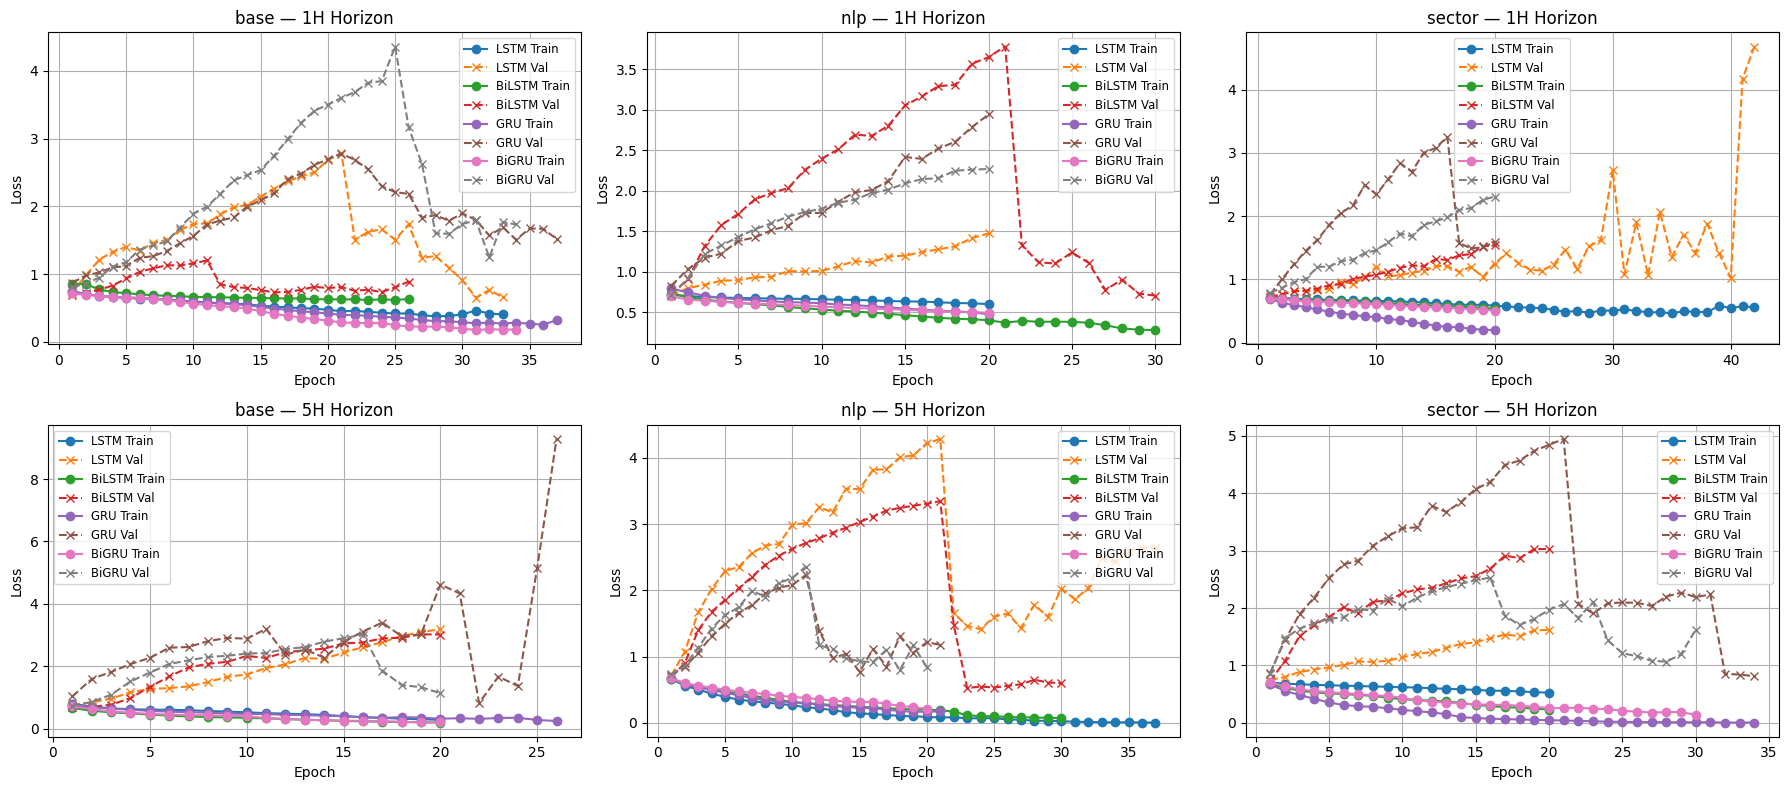

In [4]:
n_rows = len(horizons)
n_cols = len(features)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

for r, h in enumerate(horizons):
    for c, feature in enumerate(features):
        ax = axes[r][c]
        for model_name in models:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()
            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{model_name} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{model_name} Val",   marker='x', linestyle='--')
        ax.set_title(f"{feature} — {h}H Horizon")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend(fontsize='small', loc='best')

plt.tight_layout()
plt.show()

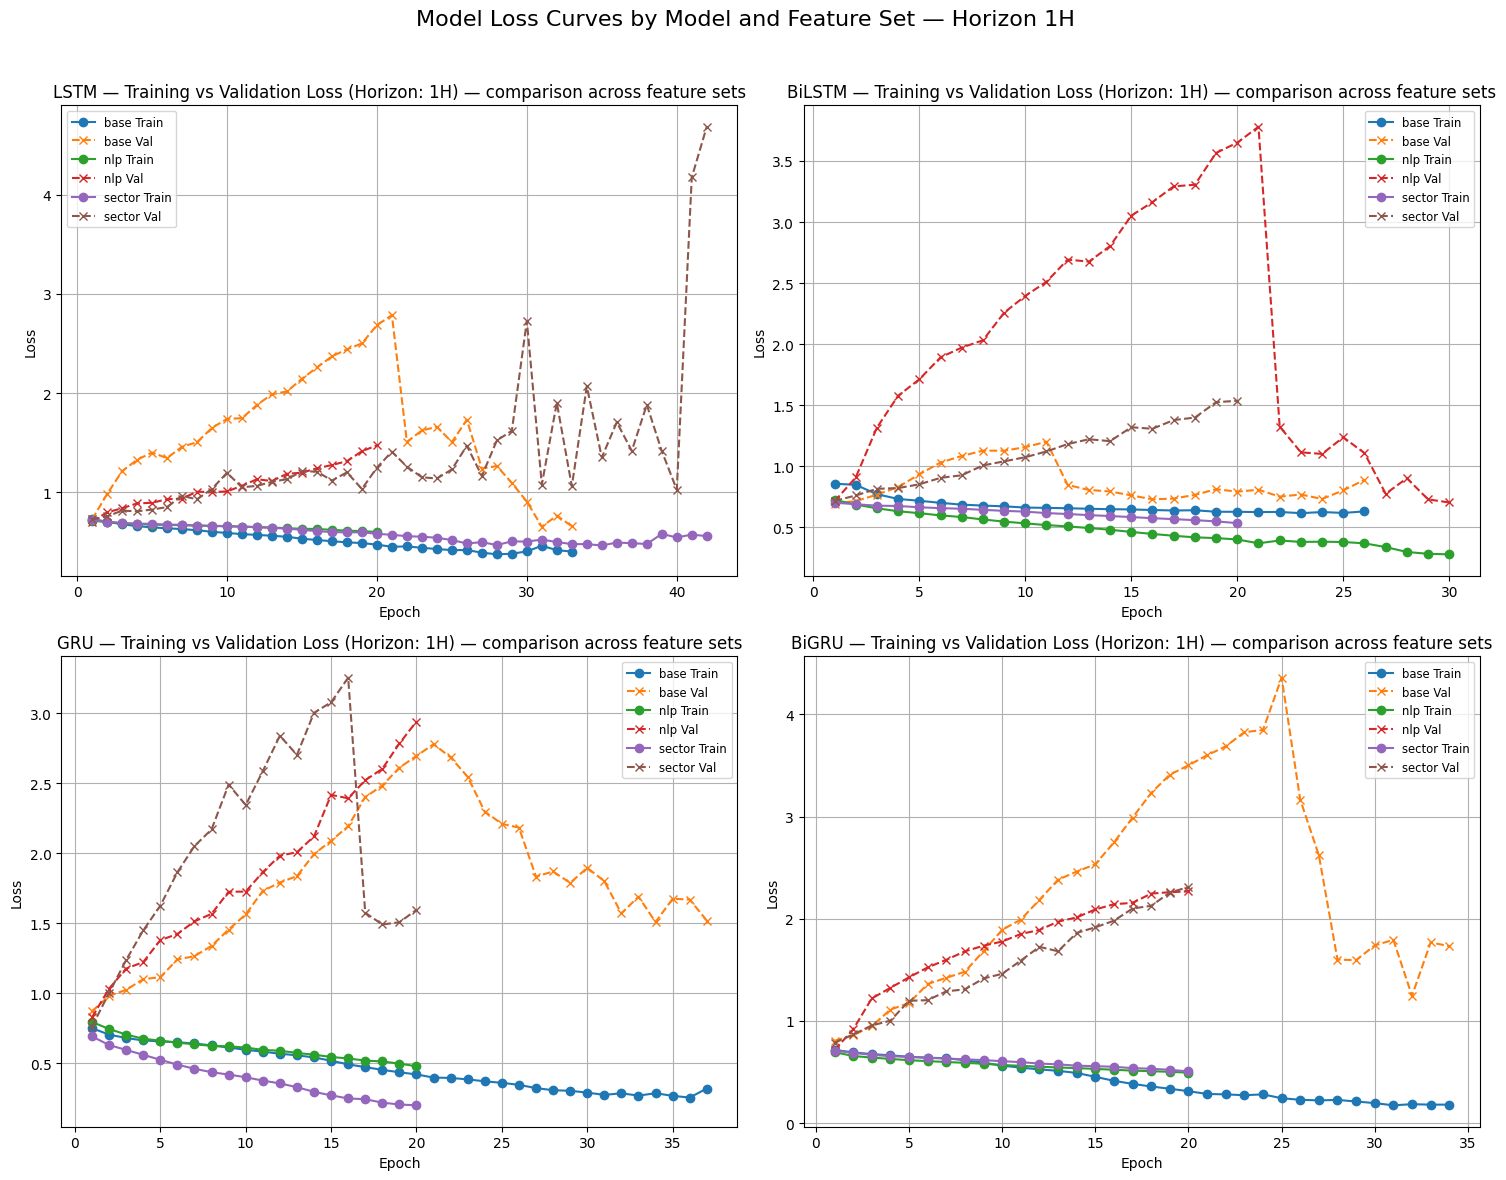

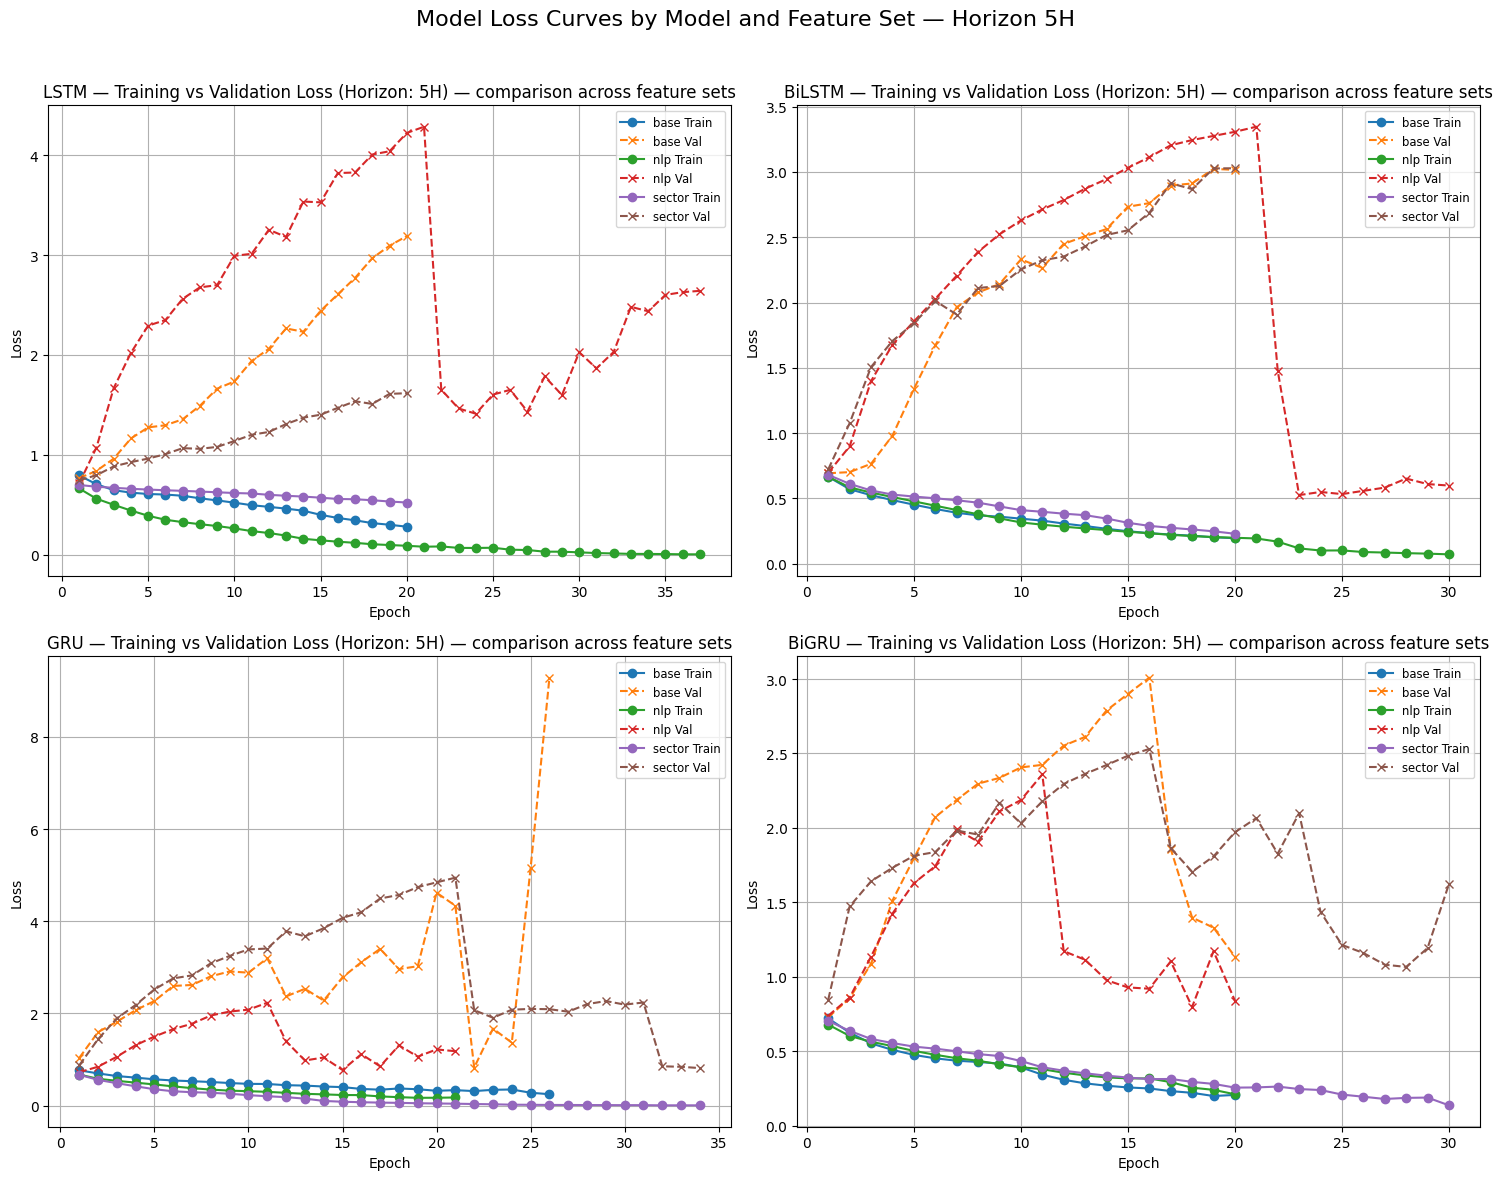

In [5]:
for h in horizons:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, model_name in enumerate(models):
        ax = axes[i]
        plotted = False
        for feature in features:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            avg_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

            ax.plot(avg_loss["epoch"], avg_loss["train_loss"], label=f"{feature} Train", marker='o')
            ax.plot(avg_loss["epoch"], avg_loss["val_loss"],   label=f"{feature} Val",   marker='x', linestyle='--')
            plotted = True

        title = f"{model_name} — Training vs Validation Loss (Horizon: {h}H) — comparison across feature sets"
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True)
        if plotted:
            ax.legend(fontsize='small', loc='best')
        else:
            ax.text(0.5, 0.5, "No data available", ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])

    # remove any extra axes if models < 4
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Model Loss Curves by Model and Feature Set — Horizon {h}H", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

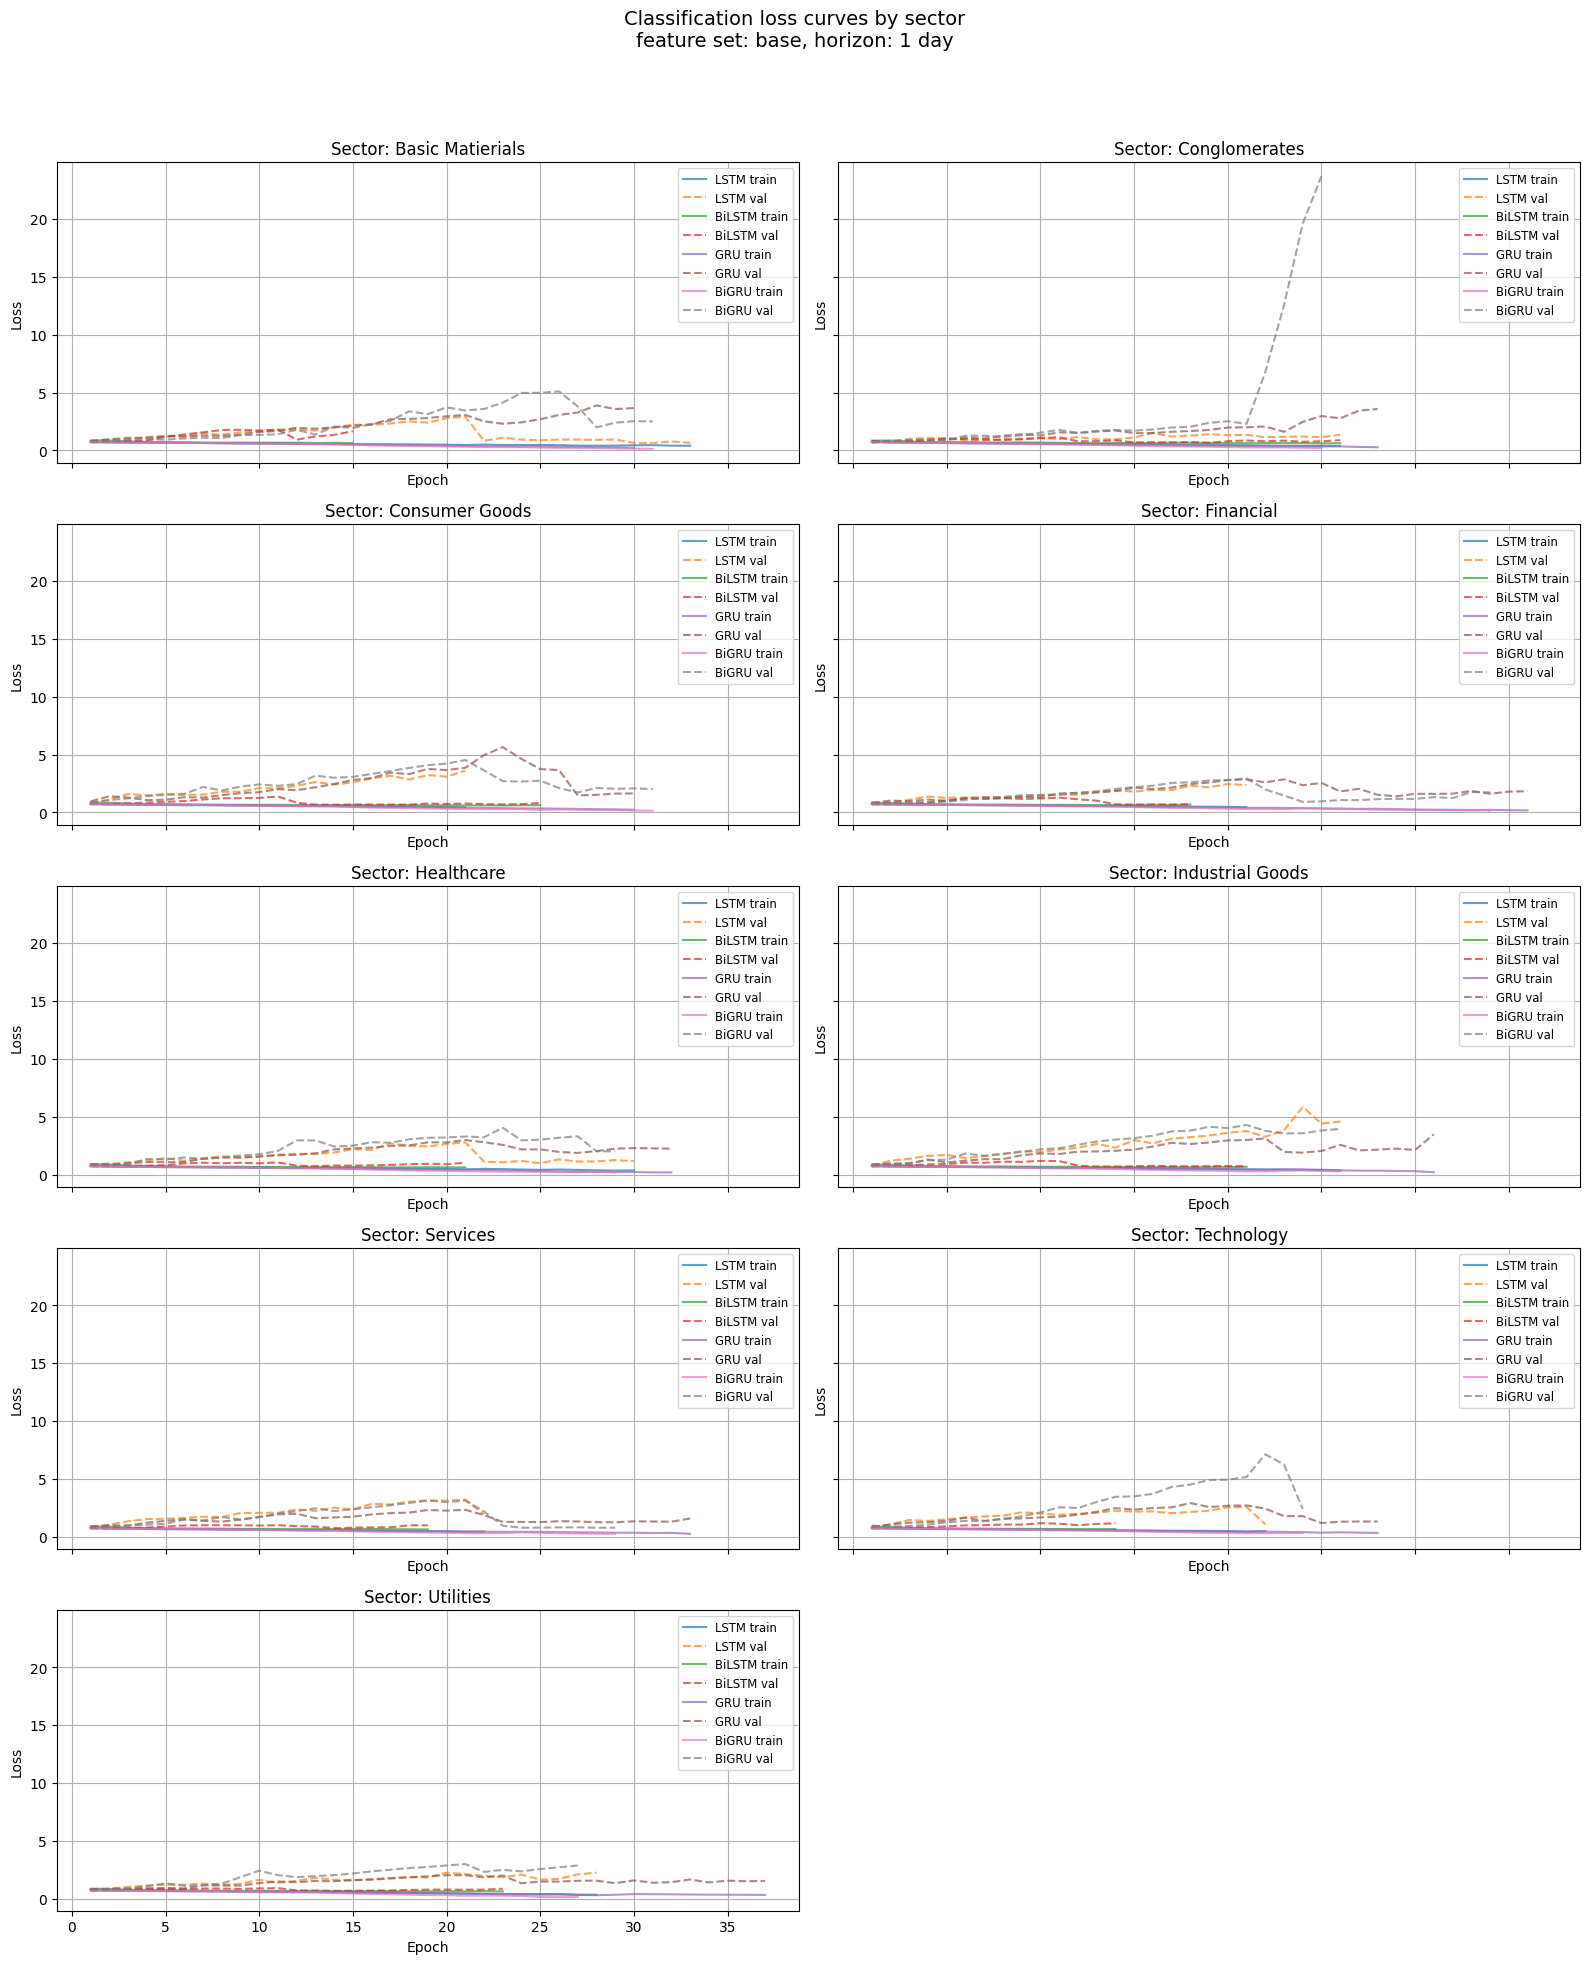

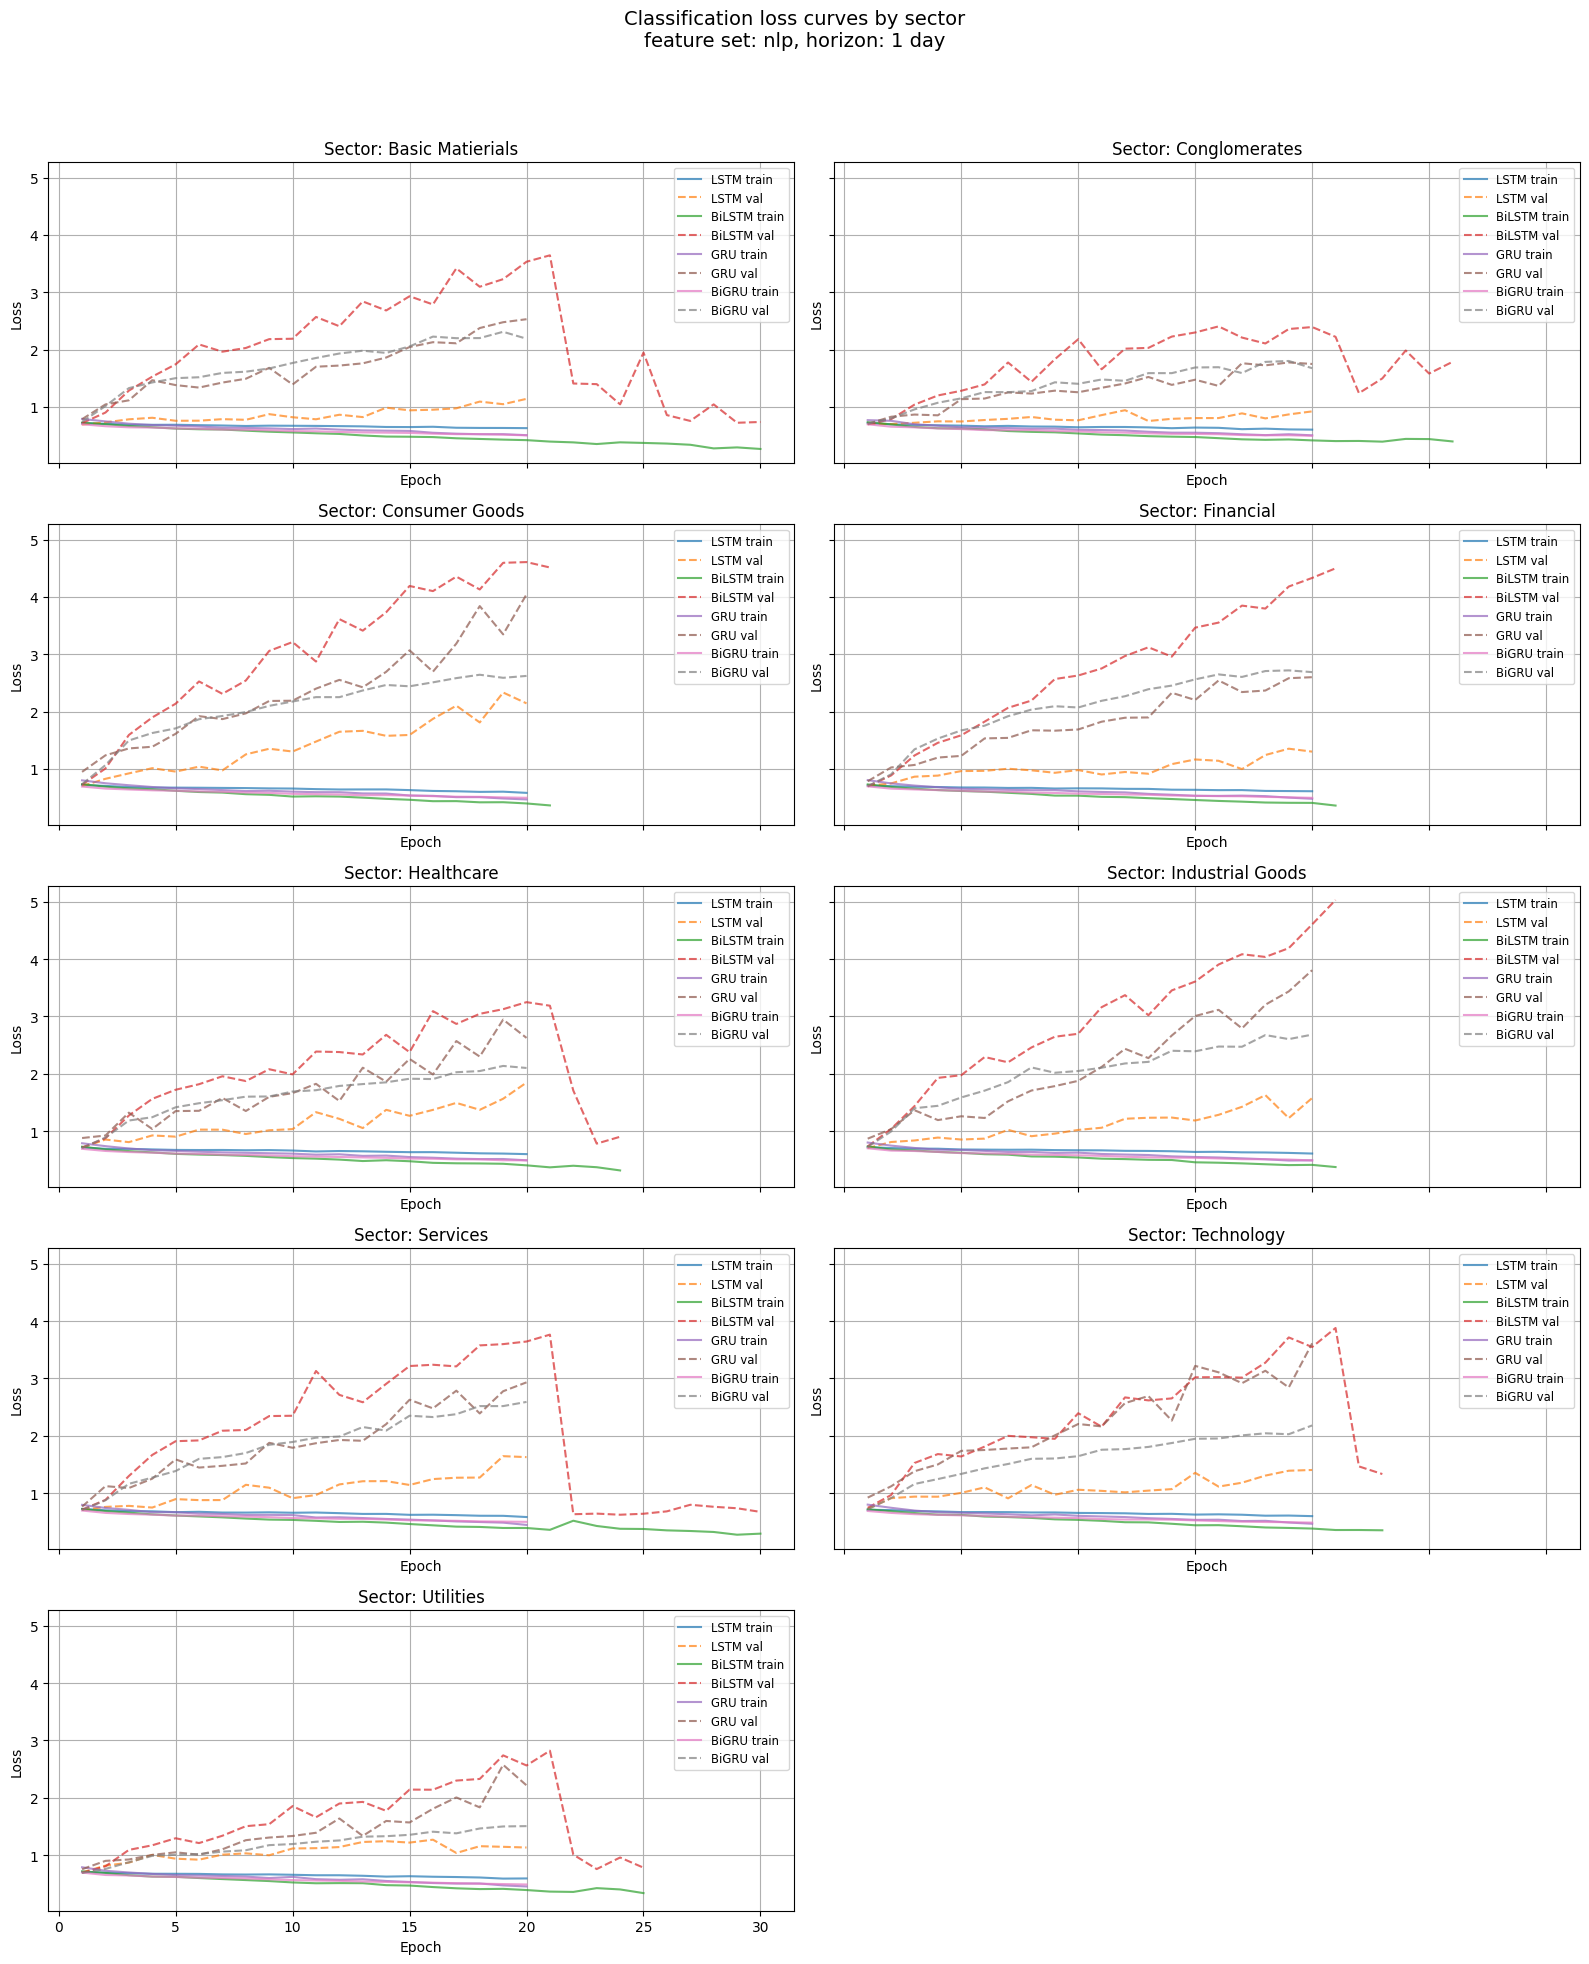

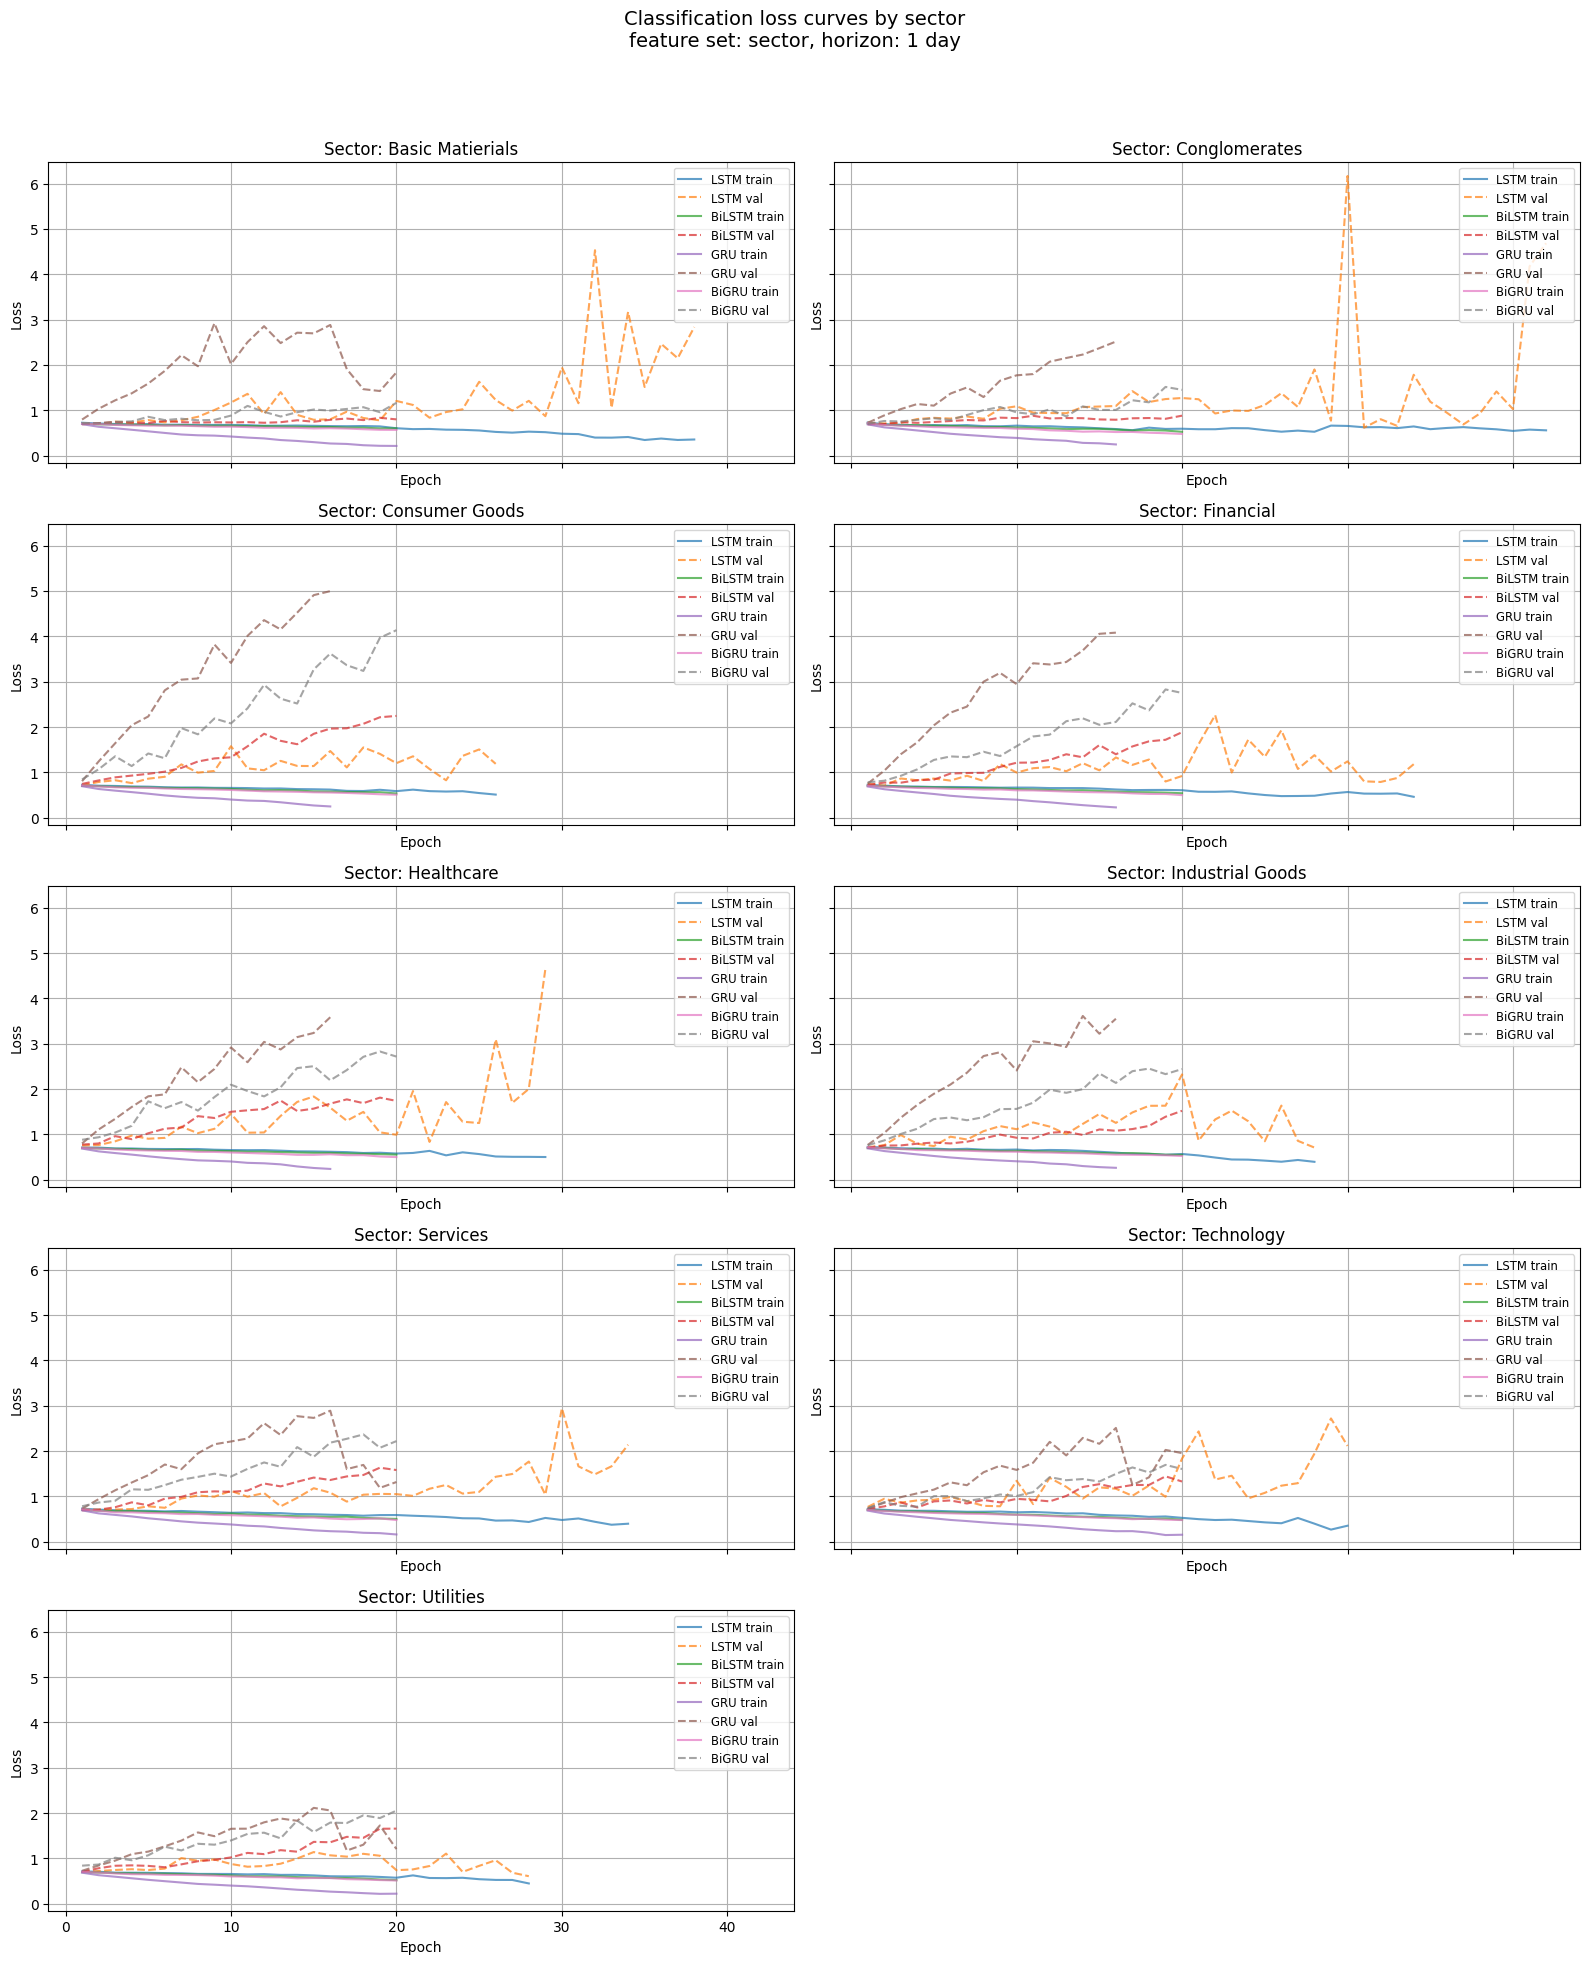

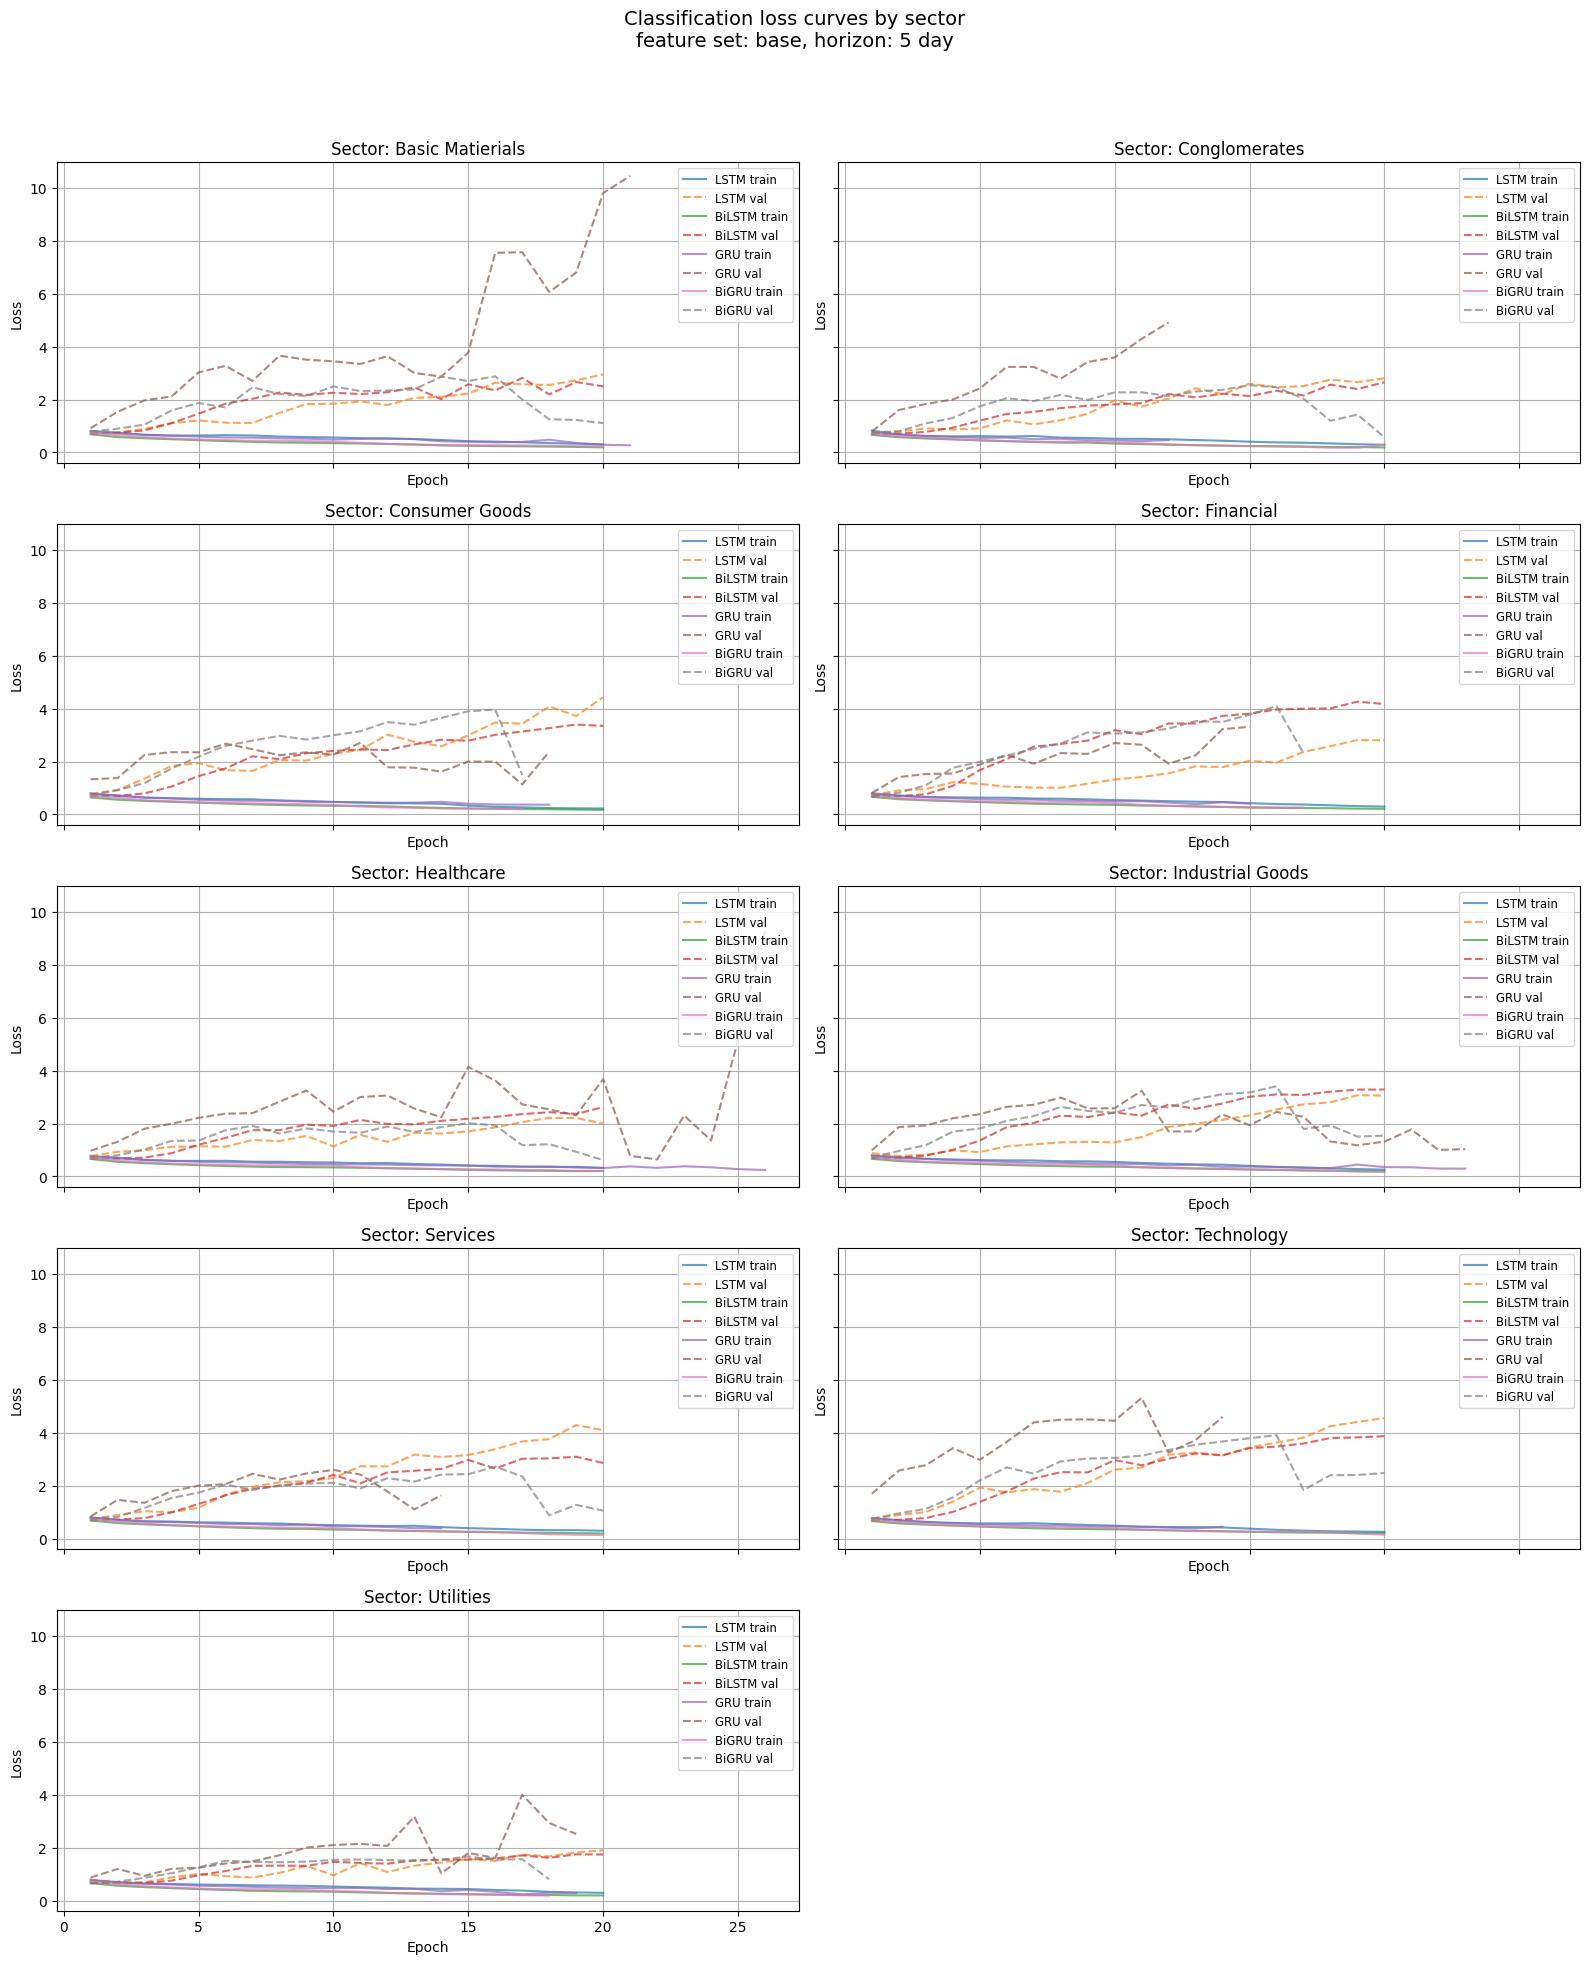

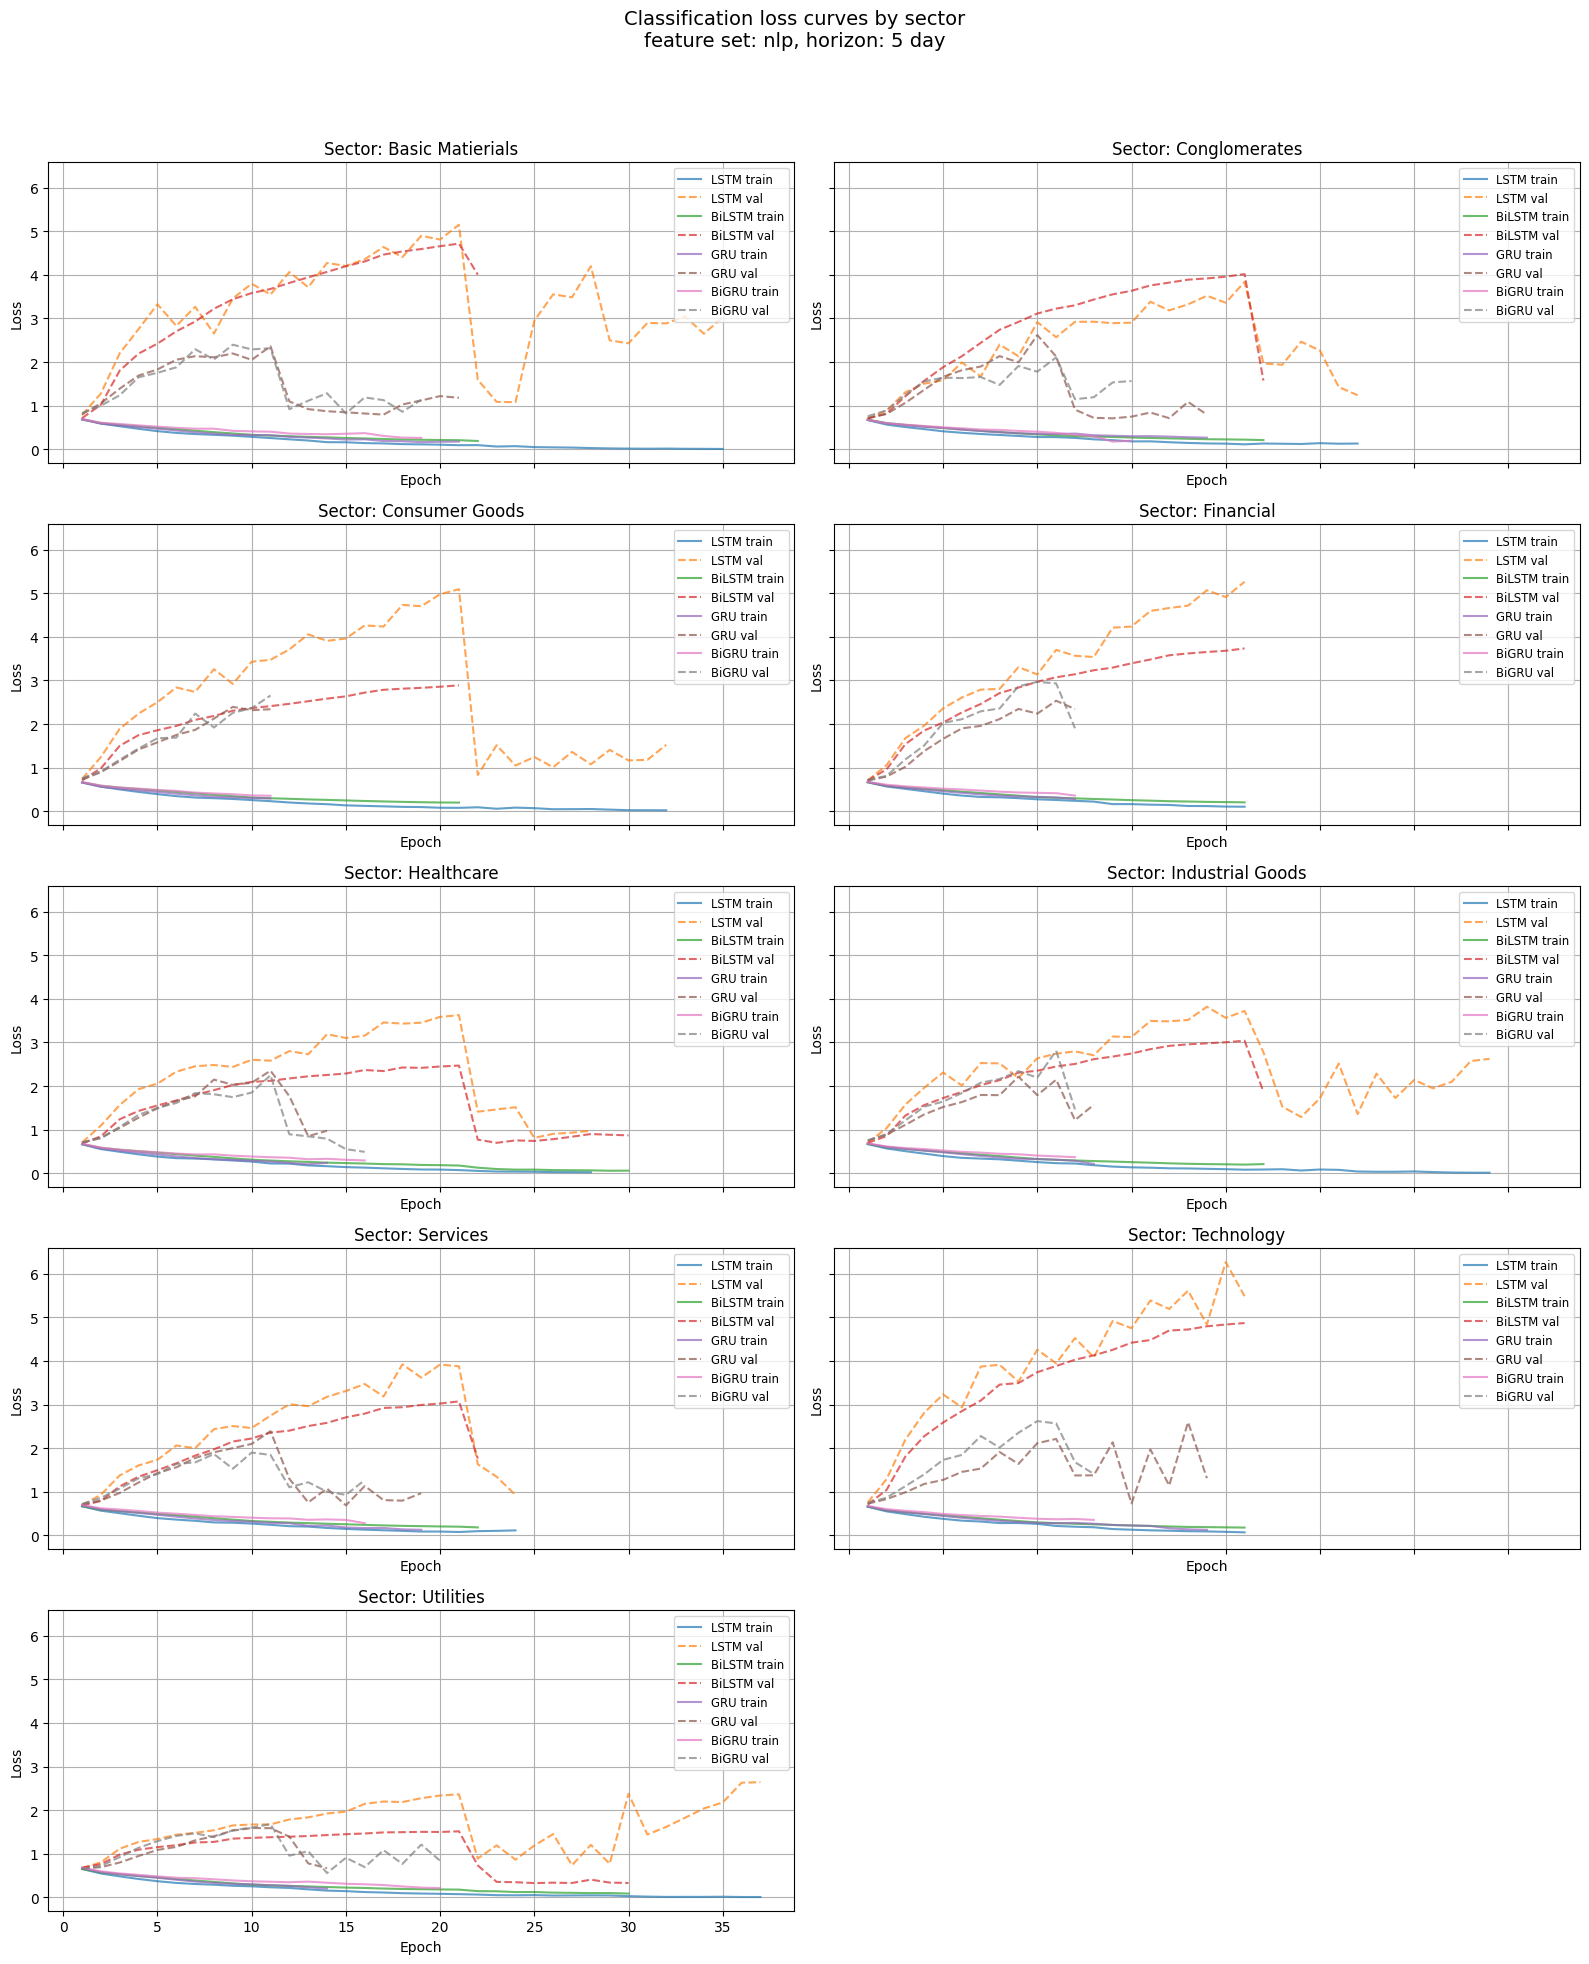

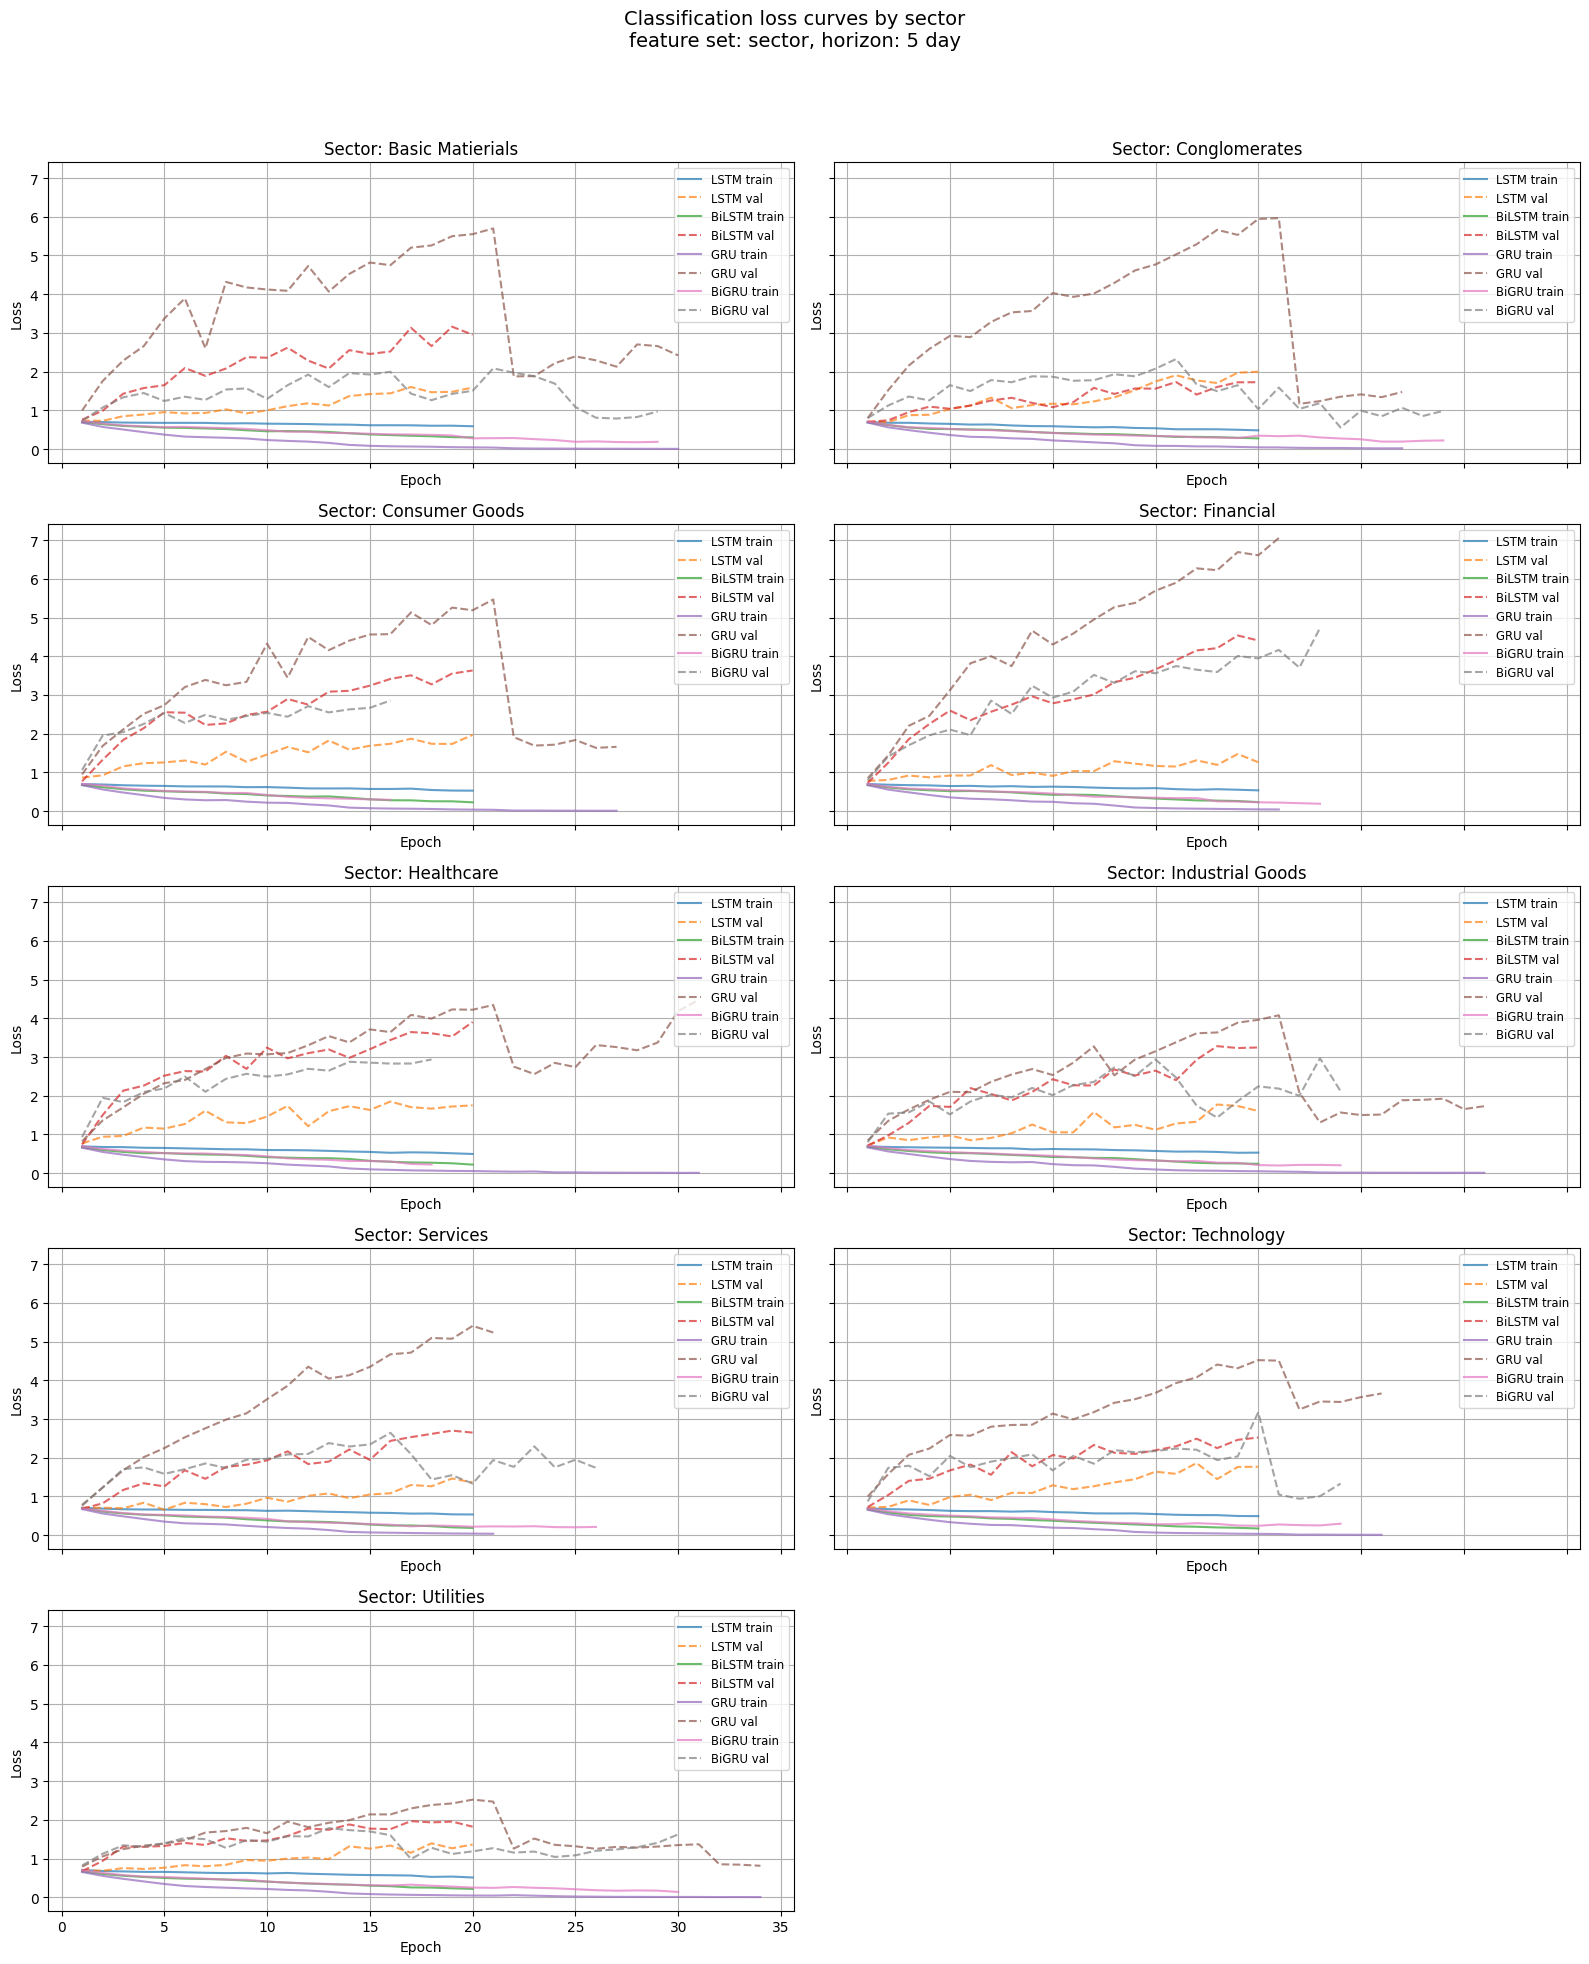

In [6]:
for h in horizons:
    for feature in features:
        # gather data just for this horizon/feature set
        pieces = []
        for model_name in models:
            csv_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_loss_curves.csv"
            if not csv_path.exists():
                continue
            df = pd.read_csv(csv_path)
            df["model"] = model_name
            pieces.append(df)
        if not pieces:                          # nothing to plot
            continue

        combined_df = pd.concat(pieces, ignore_index=True)
        grouped_loss = (combined_df
                        .groupby(["sector", "model", "epoch"])
                        [["train_loss", "val_loss"]]
                        .mean()
                        .reset_index())

        sectors = grouped_loss["sector"].unique()
        n_cols = 2
        n_rows = -(-len(sectors) // n_cols)

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(16, 4 * n_rows),
                                 sharex=True, sharey=True)
        axes = axes.flatten()

        for i, sector in enumerate(sectors):
            ax = axes[i]
            sector_data = grouped_loss[grouped_loss["sector"] == sector]
            for model_name in models:
                model_data = sector_data[sector_data["model"] == model_name]
                if model_data.empty:
                    continue
                ax.plot(model_data["epoch"], model_data["train_loss"],
                        label=f"{model_name} train",
                        linestyle="-", alpha=0.7)
                ax.plot(model_data["epoch"], model_data["val_loss"],
                        label=f"{model_name} val",
                        linestyle="--", alpha=0.7)
            ax.set_title(f"Sector: {sector}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.grid(True)
            ax.legend(fontsize="small", loc="upper right")

        # remove any extra empty subplots
        for j in range(len(sectors), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(
            f"Classification loss curves by sector\n"
            f"feature set: {feature}, horizon: {h} day",
            fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [7]:
# Overall classification results table + sector details for all models/feature sets/horizons
import pandas as pd
import numpy as np
from pathlib import Path


horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

summary_rows = []

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            params_path = CLASSIFICATION_RESULTS_PATH / feature / f"{model_name}_{h}H_params.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)
            params_df = pd.read_csv(params_path)

            # Get feature set from params file (10th column, index 9)
            feature_set_value = params_df.iloc[0, 9] if len(params_df.columns) > 9 else feature

            # Overall metrics
            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature_set_value, 
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            # Detailed printout
            print("="*50)
            print(f"Model: {model_name} | Problem: classification | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("="*50)
            print("OVERALL PERFORMANCE")
            print("="*50)
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:   {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:   {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            # Performance by sector
            if "sector" in df.columns:
                print("="*50)
                print("PERFORMANCE BY SECTOR")
                print("="*50)
                sector_stats = df.groupby('sector').agg({
                    'directional_accuracy': ['mean', 'std', 'count'],
                    'mcc': ['mean']
                })
                sector_stats.columns = ['dir_acc_mean', 'dir_acc_std', 'count', 'mcc_mean']
                sector_stats = sector_stats.sort_values('dir_acc_mean', ascending=False)
                for sector, row in sector_stats.iterrows():
                    print(f"{sector:<18} | Acc: {row['dir_acc_mean']:.3f}±{row['dir_acc_std']:.3f} | MCC: {row['mcc_mean']:.3f} | Companies: {int(row['count'])}")

            # Top performers
            if "directional_accuracy" in df.columns:
                print("="*50)
                print("TOP 10 PERFORMERS (by Directional Accuracy)")
                print("="*50)
                top = df.nlargest(10, 'directional_accuracy')
                for _, row in top.iterrows():
                    sector = row['sector'] if 'sector' in row else 'N/A'
                    company = row['company'] if 'company' in row else row.get('ticker', 'N/A')
                    print(f"{company:<18} | {sector:<15} | Acc: {row['directional_accuracy']:.3f} | MCC: {row['mcc']:.3f}")

# Print overall summary table
summary_df = pd.DataFrame(summary_rows)
# sort by horizon (ascending) then by MCC mean (descending)
summary_df = summary_df.sort_values(by=['Horizon', 'MCC Mean'], ascending=[True, False])

print("\n=== OVERALL SUMMARY TABLE (1-Day Horizon) ===")
summary_1d = summary_df[summary_df['Horizon'] == 1].drop('Horizon', axis=1)
print(summary_1d.to_string(index=False))

print("\n=== OVERALL SUMMARY TABLE (5-Day Horizon) ===")
summary_5d = summary_df[summary_df['Horizon'] == 5].drop('Horizon', axis=1)
print(summary_5d.to_string(index=False))


Model: LSTM | Problem: classification | Horizon: 1H | Feature: base
Companies analyzed: 87
Average samples per company: 1184
OVERALL PERFORMANCE
Directional Accuracy:   0.5181 (±0.0560)
Matthews Correlation:   0.0714 (±0.1022)
F1 Score:              0.4043 (±0.2552)
Precision:             0.5167 (±0.2584)
Recall:                0.4827 (±0.3794)
PERFORMANCE BY SECTOR
Financial          | Acc: 0.556±0.064 | MCC: 0.112 | Companies: 10
Consumer Goods     | Acc: 0.530±0.041 | MCC: 0.080 | Companies: 10
Utilities          | Acc: 0.528±0.056 | MCC: 0.039 | Companies: 10
Healthcare         | Acc: 0.525±0.071 | MCC: 0.107 | Companies: 10
Technology         | Acc: 0.519±0.043 | MCC: 0.101 | Companies: 10
Basic Matierials   | Acc: 0.509±0.057 | MCC: 0.047 | Companies: 10
Industrial Goods   | Acc: 0.508±0.066 | MCC: 0.060 | Companies: 10
Conglomerates      | Acc: 0.500±0.044 | MCC: 0.057 | Companies: 7
Services           | Acc: 0.483±0.036 | MCC: 0.037 | Companies: 10
TOP 10 PERFORMERS (by Directi

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

MULTICLASS_RESULTS_PATH = MULTICLASS_CLASSIFICATION_RESULTS_PATH

horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

summary_rows = []

def get_feature_set(params_df, fallback):
    if params_df is None or params_df.empty:
        return fallback
    if "params_feature_set" in params_df.columns:
        return params_df.loc[0, "params_feature_set"]
    if len(params_df.columns) > 9:
        return params_df.iloc[0, 9]
    return fallback

for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = MULTICLASS_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            params_path = MULTICLASS_RESULTS_PATH / feature / f"{model_name}_{h}H_params.csv"
            if not results_path.exists():
                print(f"[SKIP] Missing results: {results_path}")
                continue

            df = pd.read_csv(results_path)
            params_df = pd.read_csv(params_path) if params_path.exists() else pd.DataFrame()

            feature_set_value = get_feature_set(params_df, feature)

            overall = {
                "Model": model_name,
                "Horizon": h,
                "Feature Set": feature_set_value,
                "Companies": len(df),
                "Avg Samples/Company": df["n_samples"].mean() if "n_samples" in df.columns else np.nan,
                "Micro Acc Mean": df["micro_accuracy"].mean() if "micro_accuracy" in df.columns else np.nan,
                "Micro Acc Std": df["micro_accuracy"].std() if "micro_accuracy" in df.columns else np.nan,
                "Macro F1 Mean": df["macro_f1"].mean() if "macro_f1" in df.columns else np.nan,
                "Macro F1 Std": df["macro_f1"].std() if "macro_f1" in df.columns else np.nan,
                "MCC Mean": df["mcc"].mean() if "mcc" in df.columns else np.nan,
                "MCC Std": df["mcc"].std() if "mcc" in df.columns else np.nan,
                "Dir Acc Mean": df["directional_accuracy"].mean() if "directional_accuracy" in df.columns else np.nan,
                "Dir Acc Std": df["directional_accuracy"].std() if "directional_accuracy" in df.columns else np.nan,
                "F1 Mean": df["f1"].mean() if "f1" in df.columns else np.nan,
                "F1 Std": df["f1"].std() if "f1" in df.columns else np.nan,
                "Precision Mean": df["precision"].mean() if "precision" in df.columns else np.nan,
                "Precision Std": df["precision"].std() if "precision" in df.columns else np.nan,
                "Recall Mean": df["recall"].mean() if "recall" in df.columns else np.nan,
                "Recall Std": df["recall"].std() if "recall" in df.columns else np.nan,
            }
            summary_rows.append(overall)

            print("=" * 50)
            print(f"Model: {model_name} | Problem: multiclass | Horizon: {h}H | Feature: {feature}")
            print(f"Companies analyzed: {len(df)}")
            if "n_samples" in df.columns:
                print(f"Average samples per company: {df['n_samples'].mean():.0f}")
            print("=" * 50)
            print("OVERALL PERFORMANCE")
            print("=" * 50)
            if "micro_accuracy" in df.columns:
                print(f"Micro Accuracy:        {df['micro_accuracy'].mean():.4f} (±{df['micro_accuracy'].std():.4f})")
            if "macro_f1" in df.columns:
                print(f"Macro F1:              {df['macro_f1'].mean():.4f} (±{df['macro_f1'].std():.4f})")
            if "mcc" in df.columns:
                print(f"Matthews Correlation:  {df['mcc'].mean():.4f} (±{df['mcc'].std():.4f})")
            if "directional_accuracy" in df.columns:
                print(f"Directional Accuracy:  {df['directional_accuracy'].mean():.4f} (±{df['directional_accuracy'].std():.4f})")
            if "f1" in df.columns:
                print(f"F1 Score:              {df['f1'].mean():.4f} (±{df['f1'].std():.4f})")
            if "precision" in df.columns:
                print(f"Precision:             {df['precision'].mean():.4f} (±{df['precision'].std():.4f})")
            if "recall" in df.columns:
                print(f"Recall:                {df['recall'].mean():.4f} (±{df['recall'].std():.4f})")

            if "sector" in df.columns:
                print("=" * 50)
                print("PERFORMANCE BY SECTOR")
                print("=" * 50)
                sector_group = df.groupby("sector")
                sector_stats = pd.DataFrame(index=sector_group.size().index)
                sector_stats["count"] = sector_group.size()

                if "micro_accuracy" in df.columns:
                    sector_stats["micro_acc_mean"] = sector_group["micro_accuracy"].mean()
                    sector_stats["micro_acc_std"] = sector_group["micro_accuracy"].std()
                if "macro_f1" in df.columns:
                    sector_stats["macro_f1_mean"] = sector_group["macro_f1"].mean()
                    sector_stats["macro_f1_std"] = sector_group["macro_f1"].std()
                if "mcc" in df.columns:
                    sector_stats["mcc_mean"] = sector_group["mcc"].mean()
                if "directional_accuracy" in df.columns:
                    sector_stats["dir_acc_mean"] = sector_group["directional_accuracy"].mean()
                    sector_stats["dir_acc_std"] = sector_group["directional_accuracy"].std()

                sort_col = None
                for candidate in ["micro_acc_mean", "macro_f1_mean", "dir_acc_mean", "mcc_mean"]:
                    if candidate in sector_stats.columns:
                        sort_col = candidate
                        break

                if sort_col:
                    sector_stats = sector_stats.sort_values(sort_col, ascending=False)

                for sector, row in sector_stats.iterrows():
                    parts = [f"{sector:<18}"]
                    if "micro_acc_mean" in row:
                        parts.append(f"Micro Acc: {row['micro_acc_mean']:.3f}±{row.get('micro_acc_std', np.nan):.3f}")
                    if "macro_f1_mean" in row:
                        parts.append(f"Macro F1: {row['macro_f1_mean']:.3f}±{row.get('macro_f1_std', np.nan):.3f}")
                    if "dir_acc_mean" in row:
                        parts.append(f"Dir Acc: {row['dir_acc_mean']:.3f}±{row.get('dir_acc_std', np.nan):.3f}")
                    if "mcc_mean" in row:
                        parts.append(f"MCC: {row['mcc_mean']:.3f}")
                    parts.append(f"Companies: {int(row['count'])}")
                    print(" | ".join(parts))

            metric_priority = [
                ("micro_accuracy", "Micro Acc"),
                ("macro_f1", "Macro F1"),
                ("directional_accuracy", "Dir Acc"),
                ("mcc", "MCC"),
            ]
            metric_col, metric_label = None, None
            for col, label in metric_priority:
                if col in df.columns:
                    metric_col, metric_label = col, label
                    break

            if metric_col:
                print("=" * 50)
                print(f"TOP 10 PERFORMERS (by {metric_label})")
                print("=" * 50)
                top = df.nlargest(10, metric_col)
                for _, row in top.iterrows():
                    sector = row["sector"] if "sector" in row else "N/A"
                    company = row["company"] if "company" in row else row.get("ticker", "N/A")
                    metric_val = row[metric_col]
                    mcc_val = row["mcc"] if "mcc" in row else np.nan
                    print(f"{company:<18} | {sector:<15} | {metric_label}: {metric_val:.3f} | MCC: {mcc_val:.3f}")

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    print("No multiclass summary rows produced.")
else:
    summary_df = summary_df.sort_values(by=["Horizon", "MCC Mean"], ascending=[True, False])

    print("=== OVERALL SUMMARY TABLE (1-Day Horizon) ===")
    summary_1d = summary_df[summary_df["Horizon"] == 1].drop("Horizon", axis=1)
    print(summary_1d.to_string(index=False))

    print("=== OVERALL SUMMARY TABLE (5-Day Horizon) ===")
    summary_5d = summary_df[summary_df["Horizon"] == 5].drop("Horizon", axis=1)
    print(summary_5d.to_string(index=False))


Model: LSTM | Problem: multiclass | Horizon: 1H | Feature: base
Companies analyzed: 87
Average samples per company: 1189
OVERALL PERFORMANCE
Micro Accuracy:        0.1631 (±0.0684)
Macro F1:              0.1273 (±0.0629)
Matthews Correlation:  0.0696 (±0.1190)
Directional Accuracy:  0.5241 (±0.0542)
F1 Score:              0.4906 (±0.1862)
Precision:             0.5289 (±0.1516)
Recall:                0.5694 (±0.3165)
PERFORMANCE BY SECTOR
Basic Matierials   | Micro Acc: 0.202±0.057 | Macro F1: 0.165±0.064 | Dir Acc: 0.545±0.066 | MCC: 0.132 | Companies: 10
Conglomerates      | Micro Acc: 0.174±0.063 | Macro F1: 0.130±0.059 | Dir Acc: 0.516±0.063 | MCC: 0.090 | Companies: 7
Financial          | Micro Acc: 0.173±0.060 | Macro F1: 0.135±0.054 | Dir Acc: 0.525±0.035 | MCC: 0.079 | Companies: 10
Technology         | Micro Acc: 0.166±0.063 | Macro F1: 0.118±0.048 | Dir Acc: 0.528±0.064 | MCC: 0.058 | Companies: 10
Services           | Micro Acc: 0.161±0.081 | Macro F1: 0.120±0.061 | Dir Acc:

######################################################################
Horizon: 1H (sorted by MCC descending)
######################################################################
Model: BiGRU | Horizon: 1H | Feature: sector
Feature Set: sector_emotion | MCC Mean: 0.0836
Aggregated Confusion Matrix (counts):
[[ 72  58  64  44  62 110]
 [326 242 213 186 197 300]
 [222 162 141 123 106 175]
 [152 143 132 128  94 185]
 [246 234 242 197 186 333]
 [ 50  74  74  56  78 161]]


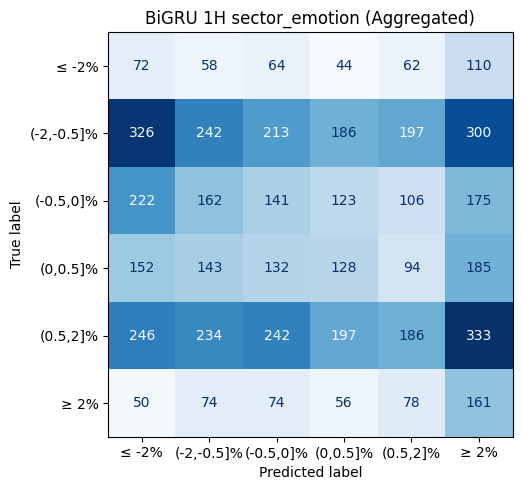

Model: GRU | Horizon: 1H | Feature: nlp
Feature Set: all_nlp | MCC Mean: 0.0760
Aggregated Confusion Matrix (counts):
[[ 81  48  71  47  45 118]
 [369 219 235 163 115 363]
 [253 151 144 122  66 193]
 [218 151 121  87  65 192]
 [378 193 187 165 135 380]
 [ 88  57  67  63  68 150]]


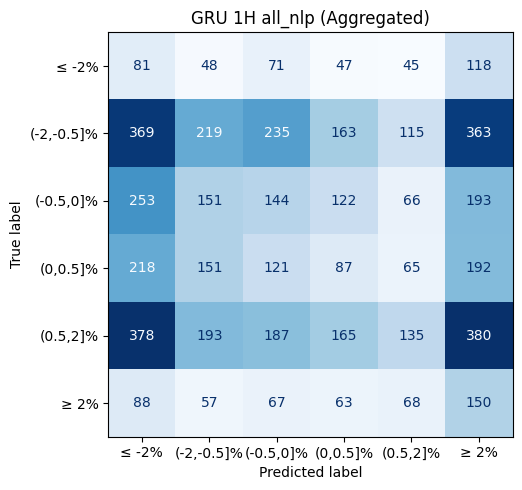

Model: LSTM | Horizon: 1H | Feature: base
Feature Set: base | MCC Mean: 0.0696
Aggregated Confusion Matrix (counts):
[[ 50  66  78  62  43 111]
 [188 242 275 215 162 382]
 [129 166 166 134 101 233]
 [105 147 148 123  97 214]
 [171 238 234 227 159 409]
 [ 42  53  69  78  83 168]]


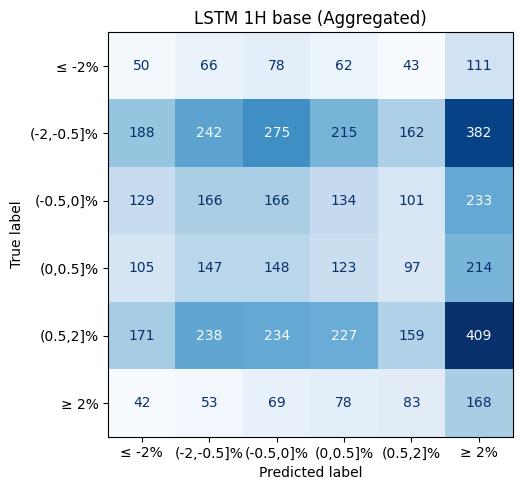

Model: BiLSTM | Horizon: 1H | Feature: sector
Feature Set: sector_unified_emotion | MCC Mean: 0.0666
Aggregated Confusion Matrix (counts):
[[ 56  49  59  84  61 101]
 [273 213 229 254 169 326]
 [182 161 147 147  94 198]
 [154 132 140 110 124 174]
 [215 215 229 249 162 368]
 [ 48  57  59  85  92 152]]


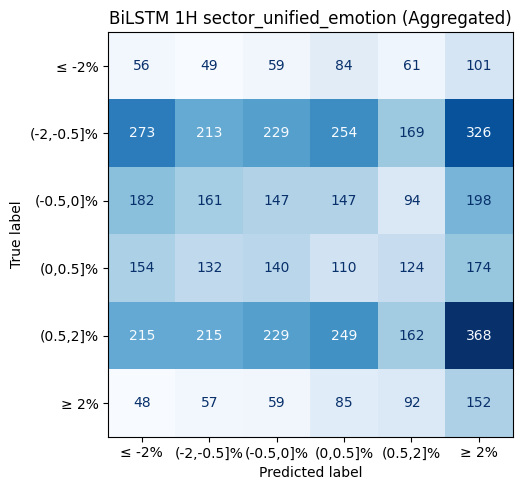

Model: BiGRU | Horizon: 1H | Feature: nlp
Feature Set: sentiment | MCC Mean: 0.0656
Aggregated Confusion Matrix (counts):
[[115  65  50  53  30  97]
 [463 238 179 136 104 344]
 [306 153 111  81  72 206]
 [240 148 131  73  57 185]
 [423 241 179 151  98 346]
 [112  67  61  45  43 165]]


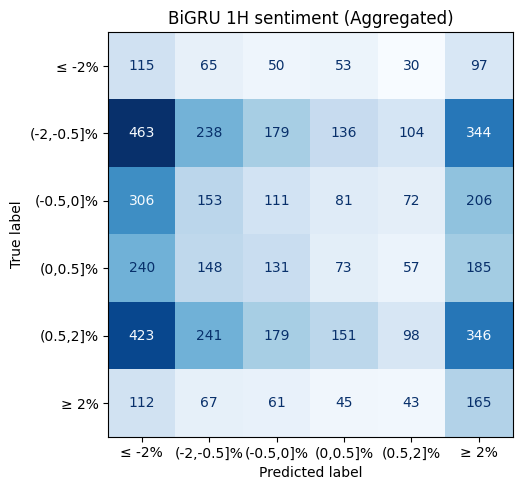

Model: BiGRU | Horizon: 1H | Feature: base
Feature Set: base | MCC Mean: 0.0632
Aggregated Confusion Matrix (counts):
[[ 61  70  57  58  65  99]
 [310 252 215 208 180 299]
 [210 169 143 123 103 181]
 [167 149 137 104  91 186]
 [270 251 229 193 150 345]
 [ 48  54  84  83  60 164]]


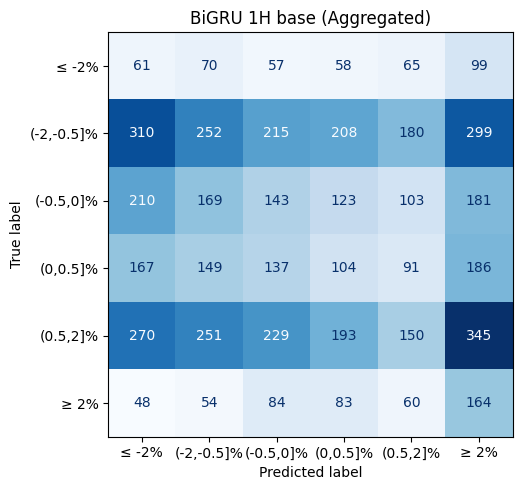

Model: GRU | Horizon: 1H | Feature: sector
Feature Set: sector_emotion | MCC Mean: 0.0624
Aggregated Confusion Matrix (counts):
[[ 32  13  19  23  74 249]
 [134 120  67 152 365 626]
 [ 94  90  47 103 232 363]
 [ 73  79  32  96 223 331]
 [ 99 117  56 170 387 609]
 [ 24  23   9  39  93 305]]


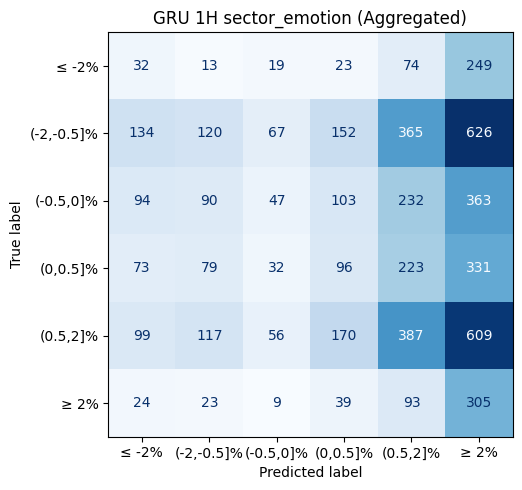

Model: BiLSTM | Horizon: 1H | Feature: base
Feature Set: base | MCC Mean: 0.0622
Aggregated Confusion Matrix (counts):
[[ 31  79  63  61  60 116]
 [190 290 254 183 166 381]
 [129 205 153  93 124 225]
 [118 167 153  91  98 207]
 [173 264 245 191 176 389]
 [ 33  76  69  60  71 184]]


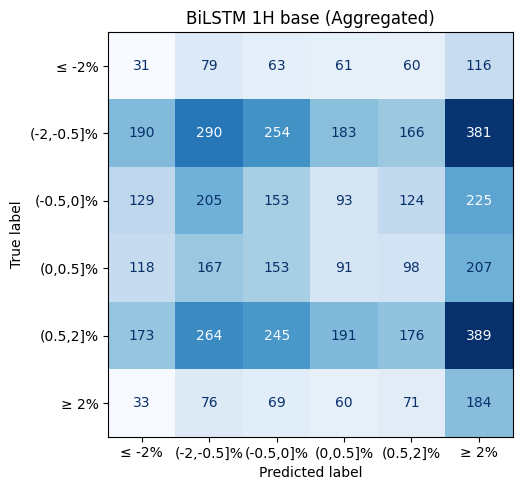

Model: LSTM | Horizon: 1H | Feature: nlp
Feature Set: sentiment | MCC Mean: 0.0571
Aggregated Confusion Matrix (counts):
[[ 34  38  20  17  94 207]
 [207 188  88  93 424 464]
 [142 128  53  75 293 238]
 [133 115  40  68 270 208]
 [188 171  88 116 439 436]
 [ 34  49  13  34 116 247]]


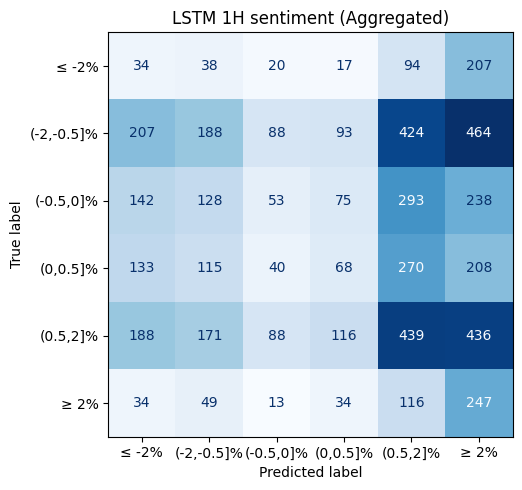

Model: BiLSTM | Horizon: 1H | Feature: nlp
Feature Set: emotion | MCC Mean: 0.0447
Aggregated Confusion Matrix (counts):
[[ 58  59  64  62  60 107]
 [251 247 182 215 185 384]
 [188 132 136 116 146 211]
 [154 136 123 106 101 214]
 [225 215 206 170 233 389]
 [ 49  60  82  62  70 170]]


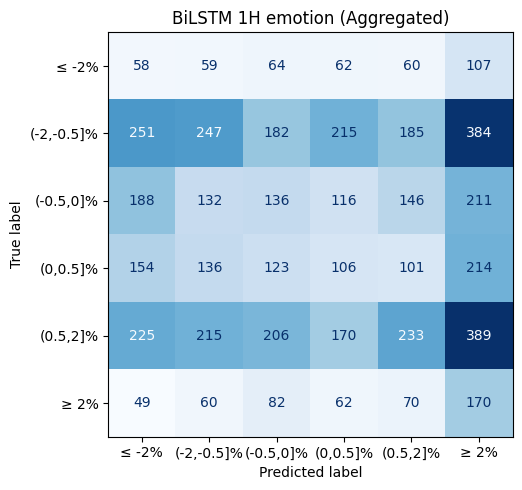

Model: GRU | Horizon: 1H | Feature: base
Feature Set: base | MCC Mean: 0.0440
Aggregated Confusion Matrix (counts):
[[ 84  73  75  65  41  72]
 [411 241 258 218 132 204]
 [289 192 144 109  80 115]
 [262 157 125 106  89  95]
 [394 275 231 185 135 218]
 [ 87  67  85  76  61 117]]


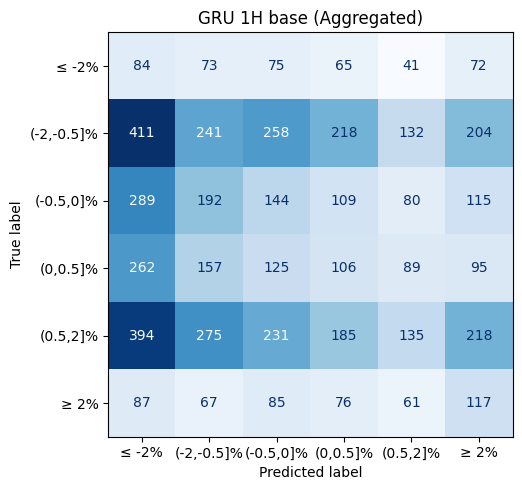

Model: LSTM | Horizon: 1H | Feature: sector
Feature Set: sector_emotion | MCC Mean: 0.0312
Aggregated Confusion Matrix (counts):
[[ 18  32  10  22 114 214]
 [111 106  51 172 473 551]
 [ 68  71  48 111 316 315]
 [ 57  74  39 113 297 254]
 [ 87  96  47 145 509 554]
 [ 23  26  10  32 127 275]]


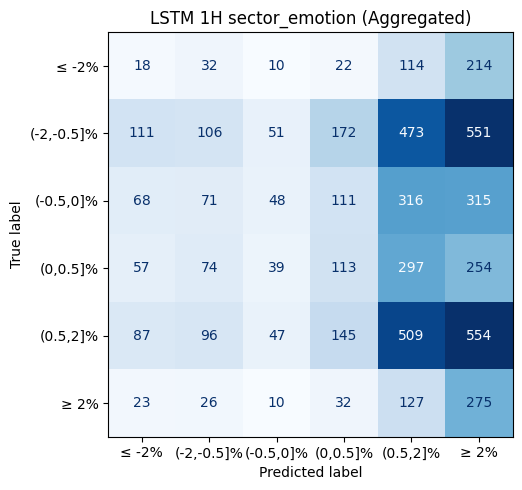

######################################################################
Horizon: 5H (sorted by MCC descending)
######################################################################
Model: BiLSTM | Horizon: 5H | Feature: base
Feature Set: base | MCC Mean: 0.1126
Aggregated Confusion Matrix (counts):
[[286  25  12  81 137 797]
 [284  38   3  68 106 540]
 [111  24   2  30  33 210]
 [ 88  17   5  36  44 195]
 [236  46  11  82 121 594]
 [211  43  12 115 143 782]]


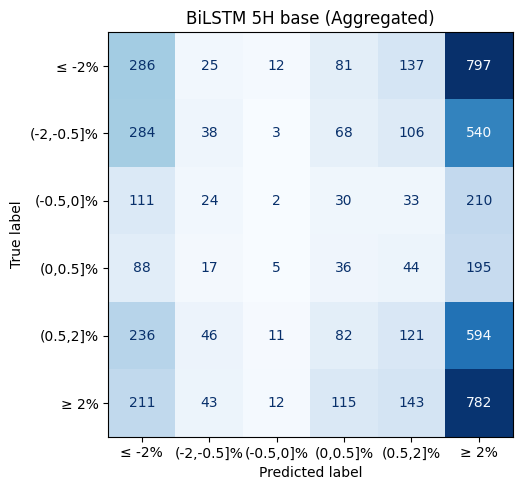

Model: BiLSTM | Horizon: 5H | Feature: nlp
Feature Set: emotion | MCC Mean: 0.1058
Aggregated Confusion Matrix (counts):
[[337  33  13  24 113 818]
 [341  33  10  38  96 521]
 [131  11   3  21  49 195]
 [123  10   4  28  38 182]
 [301  53   8  51 132 545]
 [280  73  10  43 135 765]]


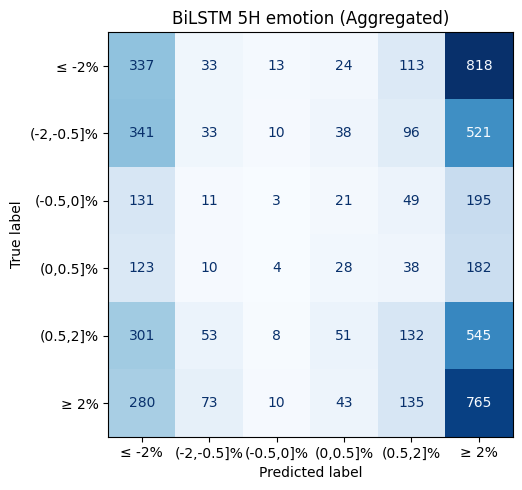

Model: BiGRU | Horizon: 5H | Feature: sector
Feature Set: sector | MCC Mean: 0.0993
Aggregated Confusion Matrix (counts):
[[302  49  22 119 168 678]
 [316  31  26 107 115 444]
 [125  14  13  35  40 183]
 [114  16  10  30  44 171]
 [302  46  36  90 126 490]
 [277  35  29 102 148 715]]


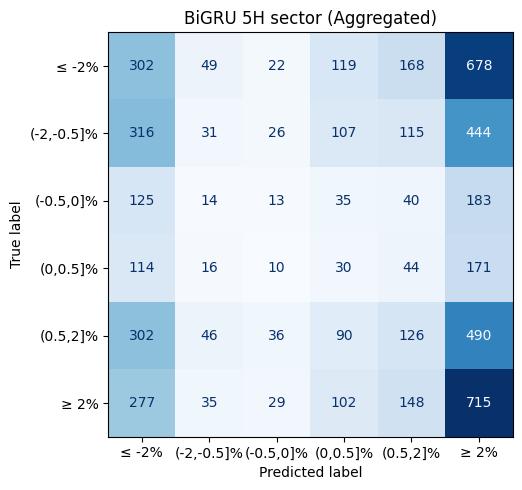

Model: BiGRU | Horizon: 5H | Feature: base
Feature Set: base | MCC Mean: 0.0991
Aggregated Confusion Matrix (counts):
[[253  42  39  84 119 801]
 [234  55  56  62 106 526]
 [110  25  20  20  38 197]
 [ 95  22  17  18  40 193]
 [242  61  40  54 114 579]
 [239  48  36  96 136 751]]


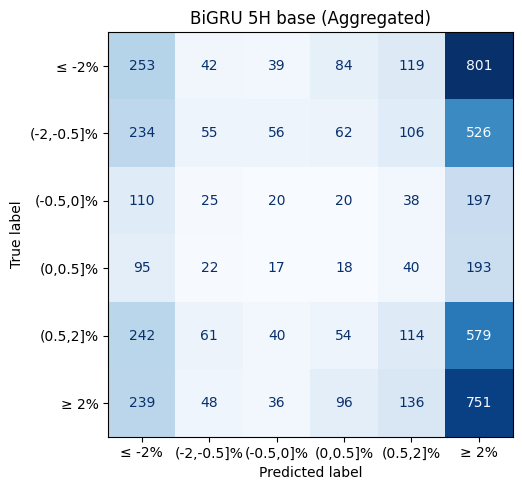

Model: GRU | Horizon: 5H | Feature: sector
Feature Set: sector_all_nlp | MCC Mean: 0.0926
Aggregated Confusion Matrix (counts):
[[265  39  20 126 154 734]
 [282  40  25  81 127 484]
 [111  14   9  36  55 185]
 [ 90  17  11  32  50 185]
 [252  67  24  83 133 531]
 [231  39  22 124 132 758]]


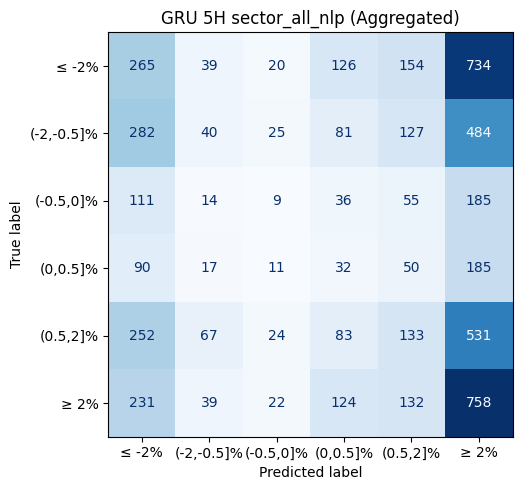

Model: GRU | Horizon: 5H | Feature: base
Feature Set: base | MCC Mean: 0.0921
Aggregated Confusion Matrix (counts):
[[287  60  26  71  89 805]
 [281  64  19  68  93 514]
 [115  27   6  29  38 195]
 [110  18   9  27  31 190]
 [309  41  26  71  94 549]
 [293  29  34  79  99 772]]


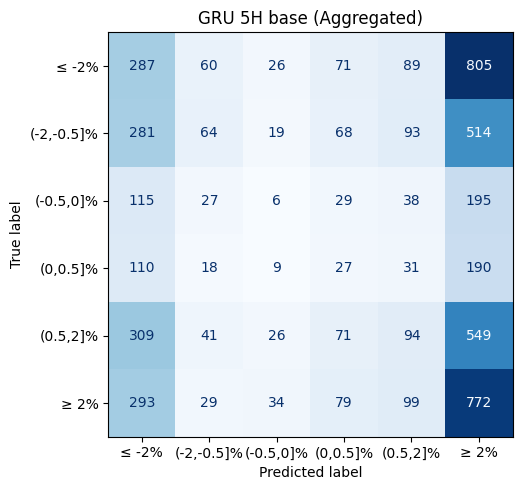

Model: GRU | Horizon: 5H | Feature: nlp
Feature Set: emotion | MCC Mean: 0.0893
Aggregated Confusion Matrix (counts):
[[251  55  26  51 142 813]
 [284  51  27  47 112 518]
 [124  17  13  24  37 195]
 [ 94  22  12  28  50 179]
 [274  47  29  61 148 531]
 [244  56  28  85 155 738]]


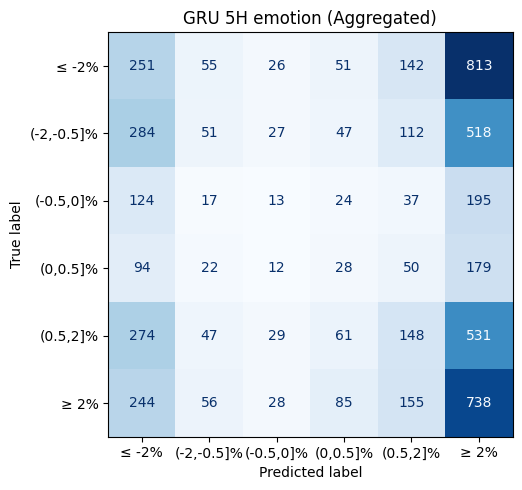

Model: LSTM | Horizon: 5H | Feature: nlp
Feature Set: sentiment | MCC Mean: 0.0882
Aggregated Confusion Matrix (counts):
[[238  37  16  77 155 815]
 [233  56  21  85 126 518]
 [ 87  34   4  30  61 194]
 [ 66  33   6  22  59 199]
 [192  68  23  94 173 540]
 [202  35  15  87 177 790]]


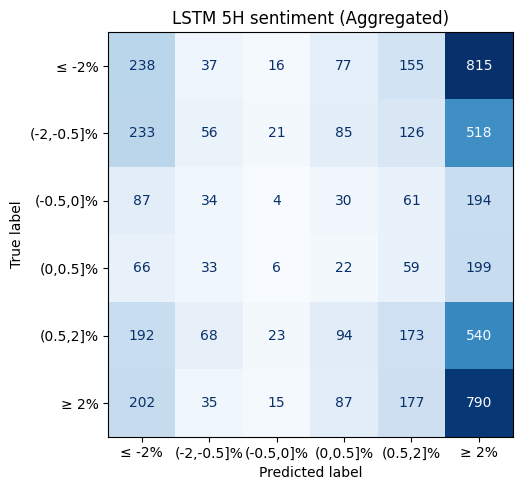

Model: BiLSTM | Horizon: 5H | Feature: sector
Feature Set: sector_finbert | MCC Mean: 0.0844
Aggregated Confusion Matrix (counts):
[[340  25   9  88  89 787]
 [300  27   1  50  98 563]
 [116   9   4  27  41 213]
 [108   9   2  24  53 189]
 [272  29   7  79 114 589]
 [257  15  12  75 118 829]]


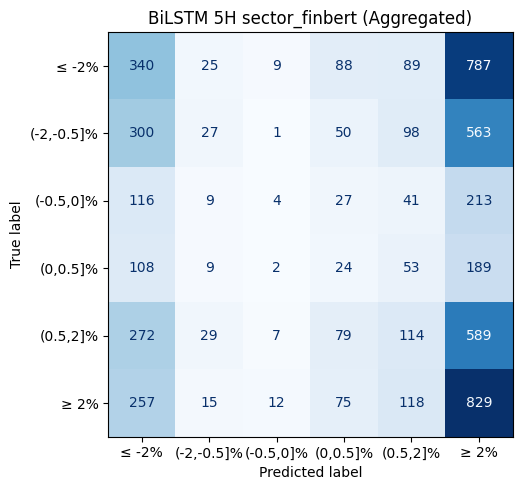

Model: LSTM | Horizon: 5H | Feature: sector
Feature Set: sector_finbert | MCC Mean: 0.0814
Aggregated Confusion Matrix (counts):
[[277  74   9 101 127 750]
 [222  51   4 100 127 535]
 [100  19   6  33  45 207]
 [ 78  17   3  45  44 198]
 [201  58  11 102 147 571]
 [189  89   8 108 118 794]]


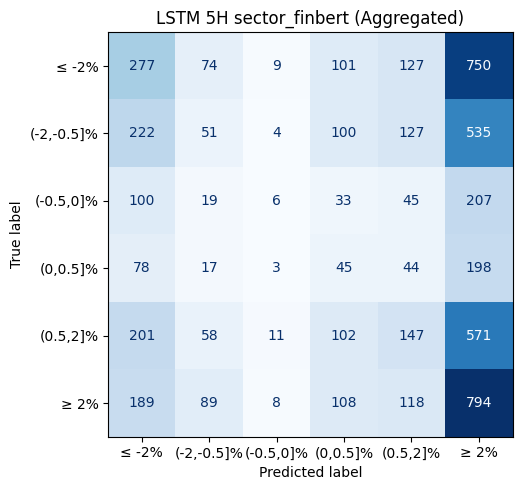

Model: BiGRU | Horizon: 5H | Feature: nlp
Feature Set: emotion | MCC Mean: 0.0813
Aggregated Confusion Matrix (counts):
[[451 241 158 209 113 166]
 [438 184 137 101  64 115]
 [167  72  56  45  22  48]
 [160  78  40  45  27  35]
 [415 233 142 104  78 118]
 [375 243 221 179 102 186]]


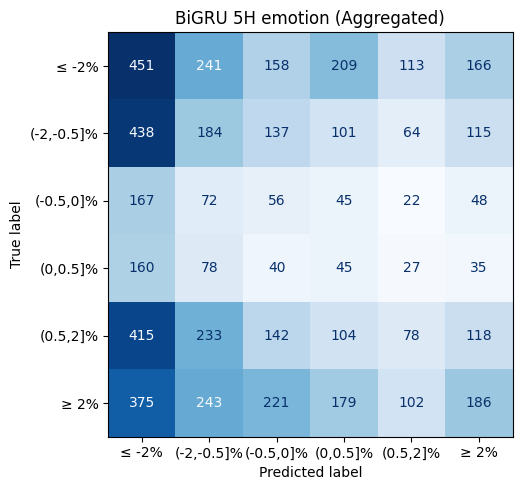

Model: LSTM | Horizon: 5H | Feature: base
Feature Set: base | MCC Mean: 0.0746
Aggregated Confusion Matrix (counts):
[[248  21  18  50 141 860]
 [261  18  12  62 156 530]
 [ 97  13   8  21  56 215]
 [ 93  11   5  28  47 201]
 [249  21  18  58 153 591]
 [201  19  17  60 193 816]]


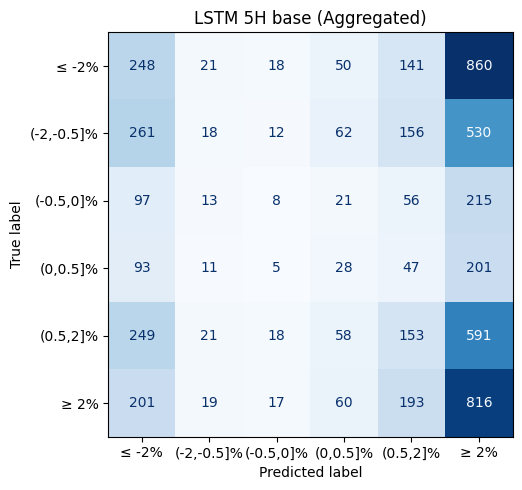

In [9]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

MULTICLASS_RESULTS_PATH = MULTICLASS_CLASSIFICATION_RESULTS_PATH

horizons = [1, 5]
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
features = ["base", "nlp", "sector"]

def plot_confusion(cm, labels, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, values_format=".2f" if cm.dtype.kind == "f" else "d", cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def parse_confusion(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.array(val)
    if isinstance(val, str):
        return np.array(ast.literal_eval(val))
    return None

def aggregate_confusions(results_df):
    matrices = results_df["confusion_matrix"].dropna().apply(parse_confusion)
    matrices = matrices[matrices.notna()]
    if matrices.empty:
        return None
    return np.sum(np.stack(matrices.values, axis=0), axis=0)

def get_feature_set(params_df, fallback):
    if params_df is None or params_df.empty:
        return fallback
    if "params_feature_set" in params_df.columns:
        return params_df.loc[0, "params_feature_set"]
    return fallback

def get_bucket_labels(df):
    if "bucket_labels" in df.columns:
        vals = df["bucket_labels"].dropna()
        if not vals.empty:
            try:
                return ast.literal_eval(vals.iloc[0])
            except Exception:
                pass
    return list(range(6))

rows = []
for h in horizons:
    for model_name in models:
        for feature in features:
            results_path = MULTICLASS_RESULTS_PATH / feature / f"{model_name}_{h}H_results.csv"
            params_path = MULTICLASS_RESULTS_PATH / feature / f"{model_name}_{h}H_params.csv"
            if not results_path.exists():
                continue

            df = pd.read_csv(results_path)
            params_df = pd.read_csv(params_path) if params_path.exists() else pd.DataFrame()
            feature_set_value = get_feature_set(params_df, feature)
            mcc_mean = df["mcc"].mean() if "mcc" in df.columns else np.nan

            rows.append({
                "horizon": h,
                "model": model_name,
                "feature": feature,
                "feature_set": feature_set_value,
                "mcc_mean": mcc_mean,
                "df": df,
            })

if not rows:
    print("No multiclass results found.")
else:
    # sort overall by MCC desc, then horizon asc to preserve split ordering
    rows_sorted = sorted(rows, key=lambda r: (np.nan_to_num(r["mcc_mean"], nan=-np.inf), -r["horizon"]), reverse=True)

    for h in horizons:
        print("" + "#" * 70)
        print(f"Horizon: {h}H (sorted by MCC descending)")
        print("#" * 70)
        subset = [r for r in rows_sorted if r["horizon"] == h]
        for r in subset:
            df = r["df"]
            print("=" * 60)
            print(f"Model: {r['model']} | Horizon: {r['horizon']}H | Feature: {r['feature']}")
            print(f"Feature Set: {r['feature_set']} | MCC Mean: {r['mcc_mean']:.4f}")

            agg_cm = aggregate_confusions(df)
            if agg_cm is None:
                print("No confusion matrices found.")
                continue

            labels = get_bucket_labels(df)
            print("Aggregated Confusion Matrix (counts):")
            print(agg_cm)
            plot_confusion(agg_cm, labels, title=f"{r['model']} {r['horizon']}H {r['feature_set']} (Aggregated)")
